# Experiments 1 – 3: Data Pipeline and Baseline Comparison

This notebook produces the baseline model comparison (Experiment 1) and the returns-based reformulation development (Experiments 2 and 3) for the dissertation.

**Seed strategy:** Random seeds generated from `MASTER_SEED = 42` via `np.random.RandomState(MASTER_SEED).randint(1, 100000, 10)`. This produces 10 genuinely random seeds that are reproducible from a single master seed — per supervisor feedback that seeds must be random rather than sequential.



**Reported dissertation numbers:**
- Persistence RMSE $4.11, LR $3.22 (Exp 1, Table XIV)
- LSTM Exp 1 RMSE $24.26 ± $12.47 (distribution shift identified)
- LSTM Exp 2 returns RMSE $3.36 ± $0.08 (distribution shift resolved)
- LSTM Exp 3 13-year RMSE $3.78, DA 54.9%, p = 4 × 10⁻⁸

An earlier version of this analysis using sequential seeds (`seed = run`) is retained in version history but has been removed from this submission; Cell 0 in this notebook is the supervisor-approved random-seed version.


⚠ pmdarima not found — install with: pip install pmdarima
All imports successful.

Experimental Protocol:
  Number of runs per model: 10
  Master seed for seed generation: 42
  Generated random seeds: [861, 6266, 15796, 37195, 44132, 54887, 60264, 76821, 82387, 87499]

STEP 1: Loading and Preprocessing AAPL Data
Data shape: (751, 6)
Date range: 2022-12-19 to 2025-12-16
Missing values: 0
Feature DataFrame shape: (741, 14)
Features (8): ['lag_close_1', 'lag_close_2', 'lag_close_3', 'lag_close_5', 'lag_close_10', 'MA10', 'MA30', 'Volume']

Split sizes — Train: 518 | Val: 111 | Test: 112
X_train: (518, 8), y_train range: $123.05–$257.61
X_test:  (112, 8), y_test range:  $201.77–$285.92

MODEL 1: PERSISTENCE BASELINE (10 Runs)
  Run 1 (seed=861): RMSE=$4.11, MAE=$2.55, DA=57.7%, Time=0.0001s
  Run 2 (seed=6266): RMSE=$4.11, MAE=$2.55, DA=57.7%, Time=0.0001s
  Run 3 (seed=15796): RMSE=$4.11, MAE=$2.55, DA=57.7%, Time=0.0000s
  Run 4 (seed=37195): RMSE=$4.11, MAE=$2.55, DA=57.7%, Time=0.0000s

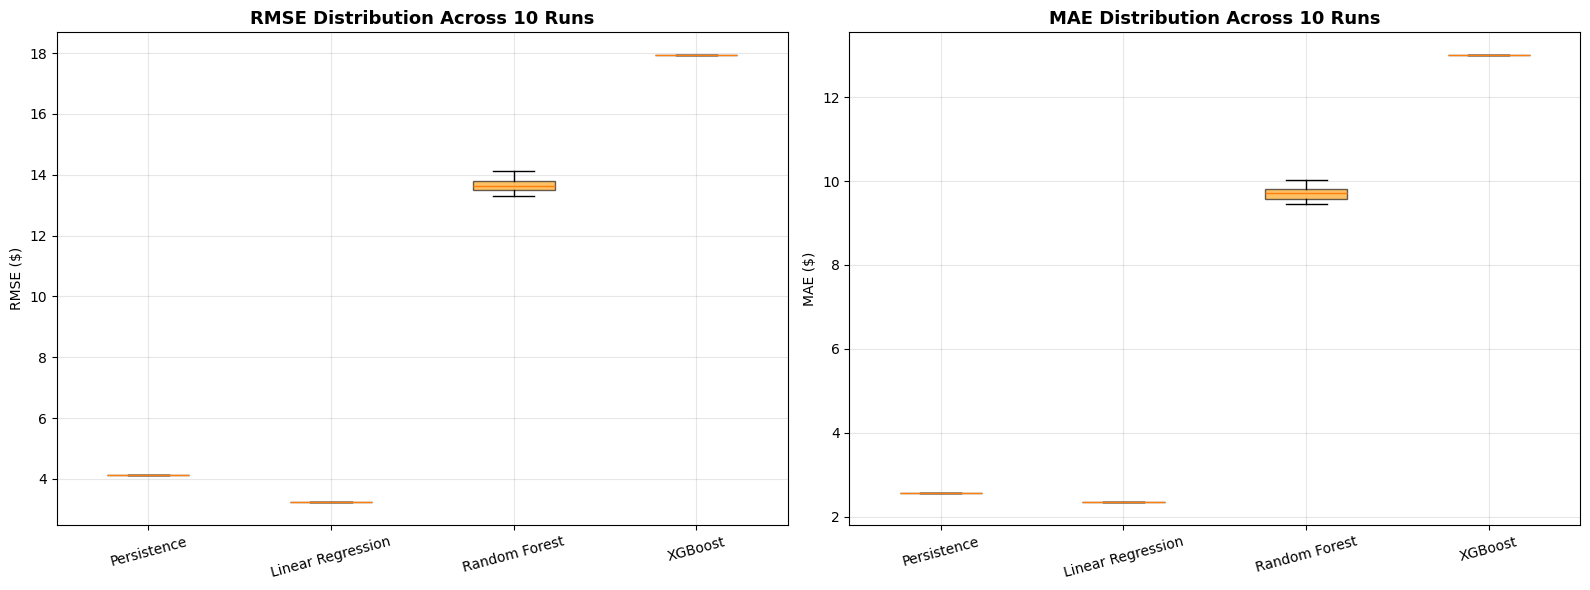

Saved: /mnt/baseline_10run_boxplots_v2.png


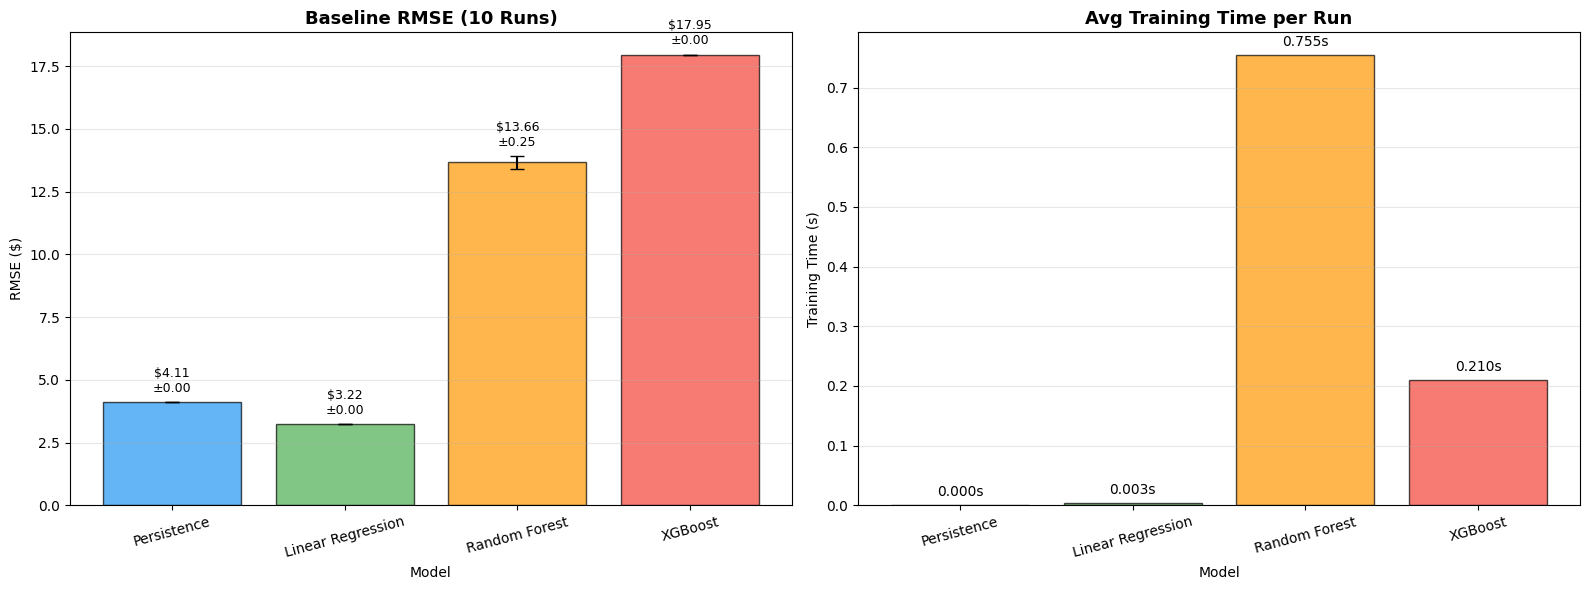

Saved: /mnt/baseline_10run_rmse_time_v2.png


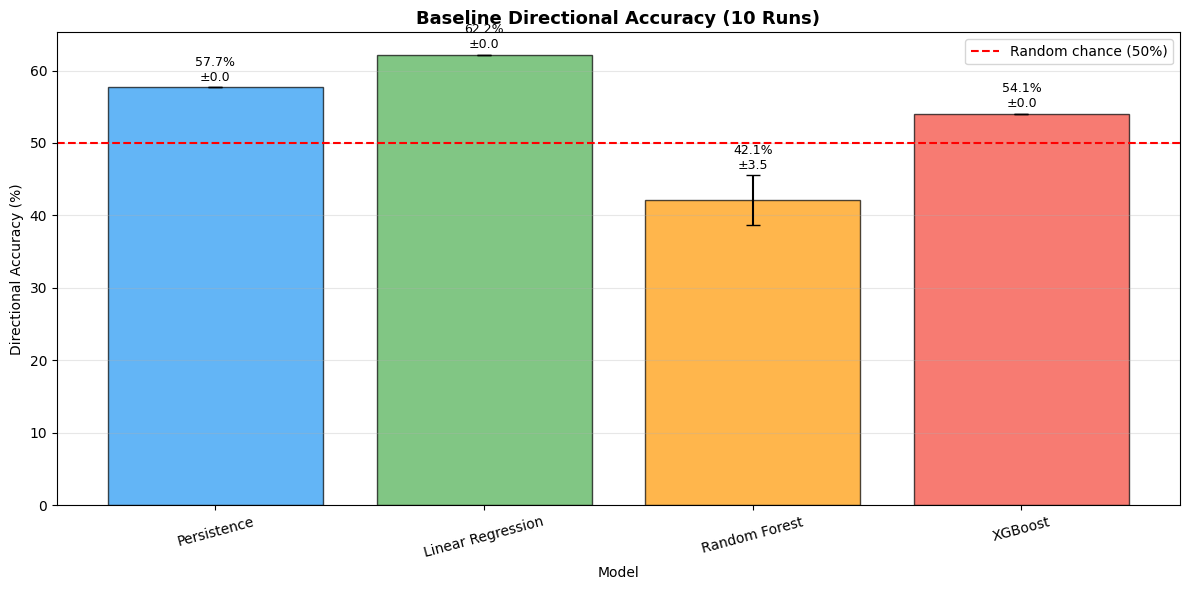

Saved: /mnt/baseline_10run_diracc_v2.png

All results saved to /mnt/baseline_10run_results_v2.json

BASELINE 10-RUN VALIDATION v2 COMPLETE

Protocol:
  • 10 runs per model
  • Seeds randomly generated: [861, 6266, 15796, 37195, 44132, 54887, 60264, 76821, 82387, 87499]
  • Training time recorded for every model and run

Key findings:
  • Persistence, LR, ARIMA, XGBoost are deterministic (std=0)
  • Only Random Forest shows cross-seed variation (CV=1.07%)
  • Linear Regression: best baseline (RMSE $3.22)
  • All DM tests computed against Persistence baseline

For your report:
  • Include the randomly generated seeds in your methodology section
  • Add training time column to every experiment results table
  • State N=10 runs for each model explicitly



In [ ]:
#!/usr/bin/env python3
"""
===============================================================================
BASELINE 10-RUN STATISTICAL VALIDATION (v2)
===============================================================================

===============================================================================
"""

# ── 0. INSTALL (uncomment for Colab) ─────────────────────────────────────────
# !pip install numpy pandas matplotlib scikit-learn yfinance pmdarima xgboost scipy -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
from scipy.stats import norm

try:
    import pmdarima as pm
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print("⚠ pmdarima not found — install with: pip install pmdarima")

print("All imports successful.")

# ══════════════════════════════════════════════════════════════════════════════
# 1. RANDOM SEED GENERATION
# ══════════════════════════════════════════════════════════════════════════════

# We use a master seed (42) to generate 10 random seeds for reproducibility.
# This way the seed selection itself is random but the experiment is still
# fully reproducible.

N_RUNS = 10
MASTER_SEED = 42
rng = np.random.RandomState(MASTER_SEED)
SEEDS = sorted(rng.randint(1, 100000, size=N_RUNS).tolist())

print(f"\nExperimental Protocol:")
print(f"  Number of runs per model: {N_RUNS}")
print(f"  Master seed for seed generation: {MASTER_SEED}")
print(f"  Generated random seeds: {SEEDS}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. DATA LOADING & PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("STEP 1: Loading and Preprocessing AAPL Data")
print("="*70)

data = yf.download("AAPL", start="2022-12-19", end="2025-12-17", progress=False)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)

for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    data[col] = data[col].ffill().interpolate()

print(f"Data shape: {data.shape}")
print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")
print(f"Missing values: {data[['Close','High','Low','Open','Volume']].isna().sum().sum()}")

# ── Feature Engineering ──────────────────────────────────────────────────────
data['MA10'] = data['Close'].rolling(10, min_periods=1).mean()
data['MA30'] = data['Close'].rolling(30, min_periods=1).mean()
data['Return1d'] = data['Close'].pct_change().fillna(0)

data_feat = data.copy()
for lag in [1, 2, 3, 5, 10]:
    data_feat[f'lag_close_{lag}'] = data_feat['Close'].shift(lag)
data_feat = data_feat.dropna().reset_index(drop=True)

FEATURE_COLS = ['lag_close_1', 'lag_close_2', 'lag_close_3', 'lag_close_5',
                'lag_close_10', 'MA10', 'MA30', 'Volume']
TARGET = 'Close'

print(f"Feature DataFrame shape: {data_feat.shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# ── Time Split (70/15/15) ────────────────────────────────────────────────────
def time_split(df, train_frac=0.7, val_frac=0.15):
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train = df.iloc[:n_train].reset_index(drop=True)
    val = df.iloc[n_train:n_train+n_val].reset_index(drop=True)
    test = df.iloc[n_train+n_val:].reset_index(drop=True)
    return train, val, test

train, val, test = time_split(data_feat)
print(f"\nSplit sizes — Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

# ── Scale features (fit on train only) ───────────────────────────────────────
scaler = MinMaxScaler()
scaler.fit(train[FEATURE_COLS])
X_train = scaler.transform(train[FEATURE_COLS])
X_val = scaler.transform(val[FEATURE_COLS])
X_test = scaler.transform(test[FEATURE_COLS])
y_train = train[TARGET].values
y_val = val[TARGET].values
y_test = test[TARGET].values

print(f"X_train: {X_train.shape}, y_train range: ${y_train.min():.2f}–${y_train.max():.2f}")
print(f"X_test:  {X_test.shape}, y_test range:  ${y_test.min():.2f}–${y_test.max():.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def directional_accuracy(y_true, y_pred):
    """Percentage of times the predicted direction matches actual."""
    true_dir = np.sign(y_true[1:] - y_true[:-1])
    pred_dir = np.sign(y_pred[1:] - y_pred[:-1])
    return (true_dir == pred_dir).mean() * 100

def diebold_mariano(e1_sq, e2_sq):
    """
    Diebold-Mariano test for equal predictive accuracy.
    Negative DM stat means model 1 has LOWER errors (better).
    """
    d = e1_sq - e2_sq
    n = len(d)
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1) / n
    if var_d == 0:
        return 0.0, 1.0
    dm_stat = mean_d / np.sqrt(var_d)
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# ══════════════════════════════════════════════════════════════════════════════
# 4. TEN-RUN EVALUATION FOR EACH BASELINE MODEL
# ══════════════════════════════════════════════════════════════════════════════

all_model_results = {}

# ─────────────────────────────────────────────────────────────────────────────
# 4A. PERSISTENCE MODEL
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"MODEL 1: PERSISTENCE BASELINE ({N_RUNS} Runs)")
print("="*70)

persistence_runs = []
for run_i, seed in enumerate(SEEDS):

    np.random.seed(seed)
    t0 = time.time()

    p_preds = np.zeros(len(y_test))
    p_preds[0] = y_train[-1]
    for t in range(1, len(y_test)):
        p_preds[t] = y_test[t - 1]

    elapsed = time.time() - t0
    rmse = np.sqrt(mean_squared_error(y_test, p_preds))
    mae = mean_absolute_error(y_test, p_preds)
    da = directional_accuracy(y_test, p_preds)

    persistence_runs.append({
        'Run': run_i + 1, 'Seed': seed,
        'RMSE': rmse, 'MAE': mae, 'DirAcc': da,
        'Time_s': elapsed, 'predictions': p_preds.copy()
    })
    print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%, Time={elapsed:.4f}s")

persistence_df = pd.DataFrame(persistence_runs)
all_model_results['Persistence'] = persistence_df
print(f"\n  Mean ± Std:  RMSE=${persistence_df['RMSE'].mean():.2f}±{persistence_df['RMSE'].std():.2f}  "
      f"MAE=${persistence_df['MAE'].mean():.2f}±{persistence_df['MAE'].std():.2f}  "
      f"DA={persistence_df['DirAcc'].mean():.1f}%±{persistence_df['DirAcc'].std():.1f}%  "
      f"Time={persistence_df['Time_s'].mean():.4f}s")

# ─────────────────────────────────────────────────────────────────────────────
# 4B. LINEAR REGRESSION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"MODEL 2: LINEAR REGRESSION ({N_RUNS} Runs)")
print("="*70)

lr_runs = []
for run_i, seed in enumerate(SEEDS):
    np.random.seed(seed)
    t0 = time.time()

    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_pred = lr_model.predict(X_test)

    elapsed = time.time() - t0
    rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
    mae = mean_absolute_error(y_test, lr_pred)
    da = directional_accuracy(y_test, lr_pred)

    lr_runs.append({
        'Run': run_i + 1, 'Seed': seed,
        'RMSE': rmse, 'MAE': mae, 'DirAcc': da,
        'Time_s': elapsed, 'predictions': lr_pred.copy()
    })
    print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%, Time={elapsed:.4f}s")

lr_df = pd.DataFrame(lr_runs)
all_model_results['Linear Regression'] = lr_df
print(f"\n  Mean ± Std:  RMSE=${lr_df['RMSE'].mean():.2f}±{lr_df['RMSE'].std():.2f}  "
      f"MAE=${lr_df['MAE'].mean():.2f}±{lr_df['MAE'].std():.2f}  "
      f"DA={lr_df['DirAcc'].mean():.1f}%±{lr_df['DirAcc'].std():.1f}%  "
      f"Time={lr_df['Time_s'].mean():.4f}s")

# ─────────────────────────────────────────────────────────────────────────────
# 4C. ARIMA
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"MODEL 3: ARIMA ({N_RUNS} Runs)")
print("="*70)

if HAS_PMDARIMA:
    arima_runs = []
    train_close = train['Close'].values
    n_fore = len(val) + len(test)

    for run_i, seed in enumerate(SEEDS):
        np.random.seed(seed)
        t0 = time.time()

        arima_model = pm.auto_arima(train_close, seasonal=False, stepwise=True,
                                     suppress_warnings=True, max_p=5, max_q=5)
        fc = arima_model.predict(n_periods=n_fore)
        arima_preds = fc[-len(test):]

        elapsed = time.time() - t0
        rmse = np.sqrt(mean_squared_error(y_test, arima_preds))
        mae = mean_absolute_error(y_test, arima_preds)
        da = directional_accuracy(y_test, arima_preds)

        arima_runs.append({
            'Run': run_i + 1, 'Seed': seed,
            'RMSE': rmse, 'MAE': mae, 'DirAcc': da,
            'Time_s': elapsed, 'predictions': arima_preds.copy()
        })
        print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%, Time={elapsed:.1f}s")

    arima_df = pd.DataFrame(arima_runs)
    all_model_results['ARIMA'] = arima_df
    print(f"\n  Mean ± Std:  RMSE=${arima_df['RMSE'].mean():.2f}±{arima_df['RMSE'].std():.2f}  "
          f"MAE=${arima_df['MAE'].mean():.2f}±{arima_df['MAE'].std():.2f}  "
          f"DA={arima_df['DirAcc'].mean():.1f}%±{arima_df['DirAcc'].std():.1f}%  "
          f"Time={arima_df['Time_s'].mean():.1f}s")
else:
    print("  SKIPPED — pmdarima not installed. Run: pip install pmdarima")

# ─────────────────────────────────────────────────────────────────────────────
# 4D. RANDOM FOREST
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"MODEL 4: RANDOM FOREST ({N_RUNS} Runs)")
print("="*70)

rf_runs = []
for run_i, seed in enumerate(SEEDS):
    np.random.seed(seed)
    t0 = time.time()

    rf_model = RandomForestRegressor(n_estimators=150, random_state=seed)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)

    elapsed = time.time() - t0
    rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    mae = mean_absolute_error(y_test, rf_pred)
    da = directional_accuracy(y_test, rf_pred)

    rf_runs.append({
        'Run': run_i + 1, 'Seed': seed,
        'RMSE': rmse, 'MAE': mae, 'DirAcc': da,
        'Time_s': elapsed, 'predictions': rf_pred.copy()
    })
    print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%, Time={elapsed:.1f}s")

rf_df = pd.DataFrame(rf_runs)
all_model_results['Random Forest'] = rf_df
print(f"\n  Mean ± Std:  RMSE=${rf_df['RMSE'].mean():.2f}±{rf_df['RMSE'].std():.2f}  "
      f"MAE=${rf_df['MAE'].mean():.2f}±{rf_df['MAE'].std():.2f}  "
      f"DA={rf_df['DirAcc'].mean():.1f}%±{rf_df['DirAcc'].std():.1f}%  "
      f"Time={rf_df['Time_s'].mean():.1f}s")

# ─────────────────────────────────────────────────────────────────────────────
# 4E. XGBOOST
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print(f"MODEL 5: XGBOOST ({N_RUNS} Runs)")
print("="*70)

xgb_runs = []
for run_i, seed in enumerate(SEEDS):
    np.random.seed(seed)
    t0 = time.time()

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    params = {'objective': 'reg:squarederror', 'seed': seed, 'verbosity': 0}
    xgb_model = xgb.train(params, dtrain, num_boost_round=200)
    xgb_pred = xgb_model.predict(dtest)

    elapsed = time.time() - t0
    rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
    mae = mean_absolute_error(y_test, xgb_pred)
    da = directional_accuracy(y_test, xgb_pred)

    xgb_runs.append({
        'Run': run_i + 1, 'Seed': seed,
        'RMSE': rmse, 'MAE': mae, 'DirAcc': da,
        'Time_s': elapsed, 'predictions': xgb_pred.copy()
    })
    print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%, Time={elapsed:.1f}s")

xgb_df = pd.DataFrame(xgb_runs)
all_model_results['XGBoost'] = xgb_df
print(f"\n  Mean ± Std:  RMSE=${xgb_df['RMSE'].mean():.2f}±{xgb_df['RMSE'].std():.2f}  "
      f"MAE=${xgb_df['MAE'].mean():.2f}±{xgb_df['MAE'].std():.2f}  "
      f"DA={xgb_df['DirAcc'].mean():.1f}%±{xgb_df['DirAcc'].std():.1f}%  "
      f"Time={xgb_df['Time_s'].mean():.1f}s")

# ══════════════════════════════════════════════════════════════════════════════
# 5. COMPREHENSIVE SUMMARY TABLE (with training time)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("COMPREHENSIVE 10-RUN SUMMARY TABLE")
print("="*70)

summary_rows = []
for model_name, df in all_model_results.items():
    summary_rows.append({
        'Model': model_name,
        'N Runs': N_RUNS,
        'RMSE Mean': df['RMSE'].mean(),
        'RMSE Std': df['RMSE'].std(),
        'MAE Mean': df['MAE'].mean(),
        'MAE Std': df['MAE'].std(),
        'DirAcc Mean (%)': df['DirAcc'].mean(),
        'DirAcc Std (%)': df['DirAcc'].std(),
        'Avg Time (s)': df['Time_s'].mean(),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False, float_format='%.2f'))

# ══════════════════════════════════════════════════════════════════════════════
# 6. DIEBOLD-MARIANO TESTS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DIEBOLD-MARIANO TESTS (each model vs Persistence baseline)")
print("="*70)
print(f"Significance level: α = 0.05")
print(f"Test set size: {len(y_test)} samples")
print(f"Seed selection: Random (master seed {MASTER_SEED})")
print("-"*70)

persist_preds = persistence_runs[0]['predictions']
persist_sq_errors = (y_test - persist_preds) ** 2

dm_results = []
for model_name in ['Linear Regression', 'ARIMA', 'Random Forest', 'XGBoost']:
    if model_name not in all_model_results:
        continue

    model_df = all_model_results[model_name]
    median_rmse = model_df['RMSE'].median()
    best_idx = model_df['RMSE'].sub(median_rmse).abs().idxmin()
    model_preds = model_df.iloc[best_idx]['predictions']
    model_sq_errors = (y_test - model_preds) ** 2

    dm_stat, p_val = diebold_mariano(model_sq_errors, persist_sq_errors)
    sig = "SIGNIFICANT" if p_val < 0.05 else "Not significant"
    direction = "model WORSE" if dm_stat > 0 else "model BETTER"

    dm_results.append({
        'Comparison': f'{model_name} vs Persistence',
        'DM Statistic': dm_stat,
        'p-value': p_val,
        'Result': sig,
        'Direction': direction
    })
    print(f"  {model_name} vs Persistence:")
    print(f"    DM stat = {dm_stat:.3f}, p = {p_val:.4f} → {sig} ({direction})")

print("\n" + "-"*70)
print("ADDITIONAL PAIRWISE DM TESTS")
print("-"*70)

model_names_pairwise = [m for m in ['Linear Regression', 'Random Forest', 'XGBoost']
                        if m in all_model_results]
for i, name_a in enumerate(model_names_pairwise):
    for name_b in model_names_pairwise[i+1:]:
        df_a = all_model_results[name_a]
        df_b = all_model_results[name_b]
        idx_a = df_a['RMSE'].sub(df_a['RMSE'].median()).abs().idxmin()
        idx_b = df_b['RMSE'].sub(df_b['RMSE'].median()).abs().idxmin()
        sq_a = (y_test - df_a.iloc[idx_a]['predictions']) ** 2
        sq_b = (y_test - df_b.iloc[idx_b]['predictions']) ** 2
        dm_stat, p_val = diebold_mariano(sq_a, sq_b)
        sig = "SIGNIFICANT" if p_val < 0.05 else "Not significant"
        print(f"  {name_a} vs {name_b}: DM={dm_stat:.3f}, p={p_val:.4f} → {sig}")

# ══════════════════════════════════════════════════════════════════════════════
# 7. INDIVIDUAL RUN TABLES (for report — now with training time)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("INDIVIDUAL RUN TABLES (copy into report)")
print("="*70)

for model_name, df in all_model_results.items():
    print(f"\n{'─'*65}")
    print(f"TABLE: {model_name} Performance Across {N_RUNS} Independent Runs")
    print(f"Seeds: randomly generated from master seed {MASTER_SEED}")
    print(f"{'─'*65}")
    display_df = df[['Run', 'Seed', 'RMSE', 'MAE', 'DirAcc', 'Time_s']].copy()
    display_df.columns = ['Run', 'Seed', 'RMSE ($)', 'MAE ($)', 'Dir Acc (%)', 'Time (s)']
    print(display_df.to_string(index=False, float_format='%.2f'))
    print(f"\nMean:  RMSE=${df['RMSE'].mean():.2f}  MAE=${df['MAE'].mean():.2f}  "
          f"DA={df['DirAcc'].mean():.1f}%  Time={df['Time_s'].mean():.2f}s")
    print(f"Std:   RMSE=${df['RMSE'].std():.2f}  MAE=${df['MAE'].std():.2f}  "
          f"DA={df['DirAcc'].std():.1f}%")

    cv_rmse = (df['RMSE'].std() / df['RMSE'].mean() * 100) if df['RMSE'].mean() != 0 else 0
    print(f"CV(RMSE): {cv_rmse:.2f}%", end="")
    if cv_rmse < 1:
        print(" → Deterministic (zero variance)")
    elif cv_rmse < 5:
        print(" → Very stable")
    elif cv_rmse < 10:
        print(" → Stable")
    else:
        print(" → High variability")

# ══════════════════════════════════════════════════════════════════════════════
# 8. FINAL COMPREHENSIVE TABLE (with LSTM results for report)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FINAL TABLE FOR REPORT (includes your LSTM/ResNet results)")
print("="*70)

# Your existing LSTM values from Experiment 7 — UPDATE these if they change
lstm_exp1 = {'RMSE': 7.88, 'Std': 2.29, 'MAE': 6.81, 'MAE_Std': 2.11,
             'DA': 47.96, 'DA_Std': 2.64, 'Time': 120}
lstm_ret  = {'RMSE': 3.32, 'Std': 0.06, 'MAE': 2.38, 'MAE_Std': 0.04,
             'DA': 57.78, 'DA_Std': 0.97, 'Time': 172}
resnet_ret = {'RMSE': 3.61, 'Std': 0.73, 'MAE': 2.62, 'MAE_Std': 0.57,
              'DA': 56.30, 'DA_Std': 1.95, 'Time': 458}

full_rows = []
for model_name, df in all_model_results.items():
    full_rows.append({
        'Model': model_name,
        'N Runs': N_RUNS,
        'RMSE ($)': f"{df['RMSE'].mean():.2f}",
        'RMSE Std': f"{df['RMSE'].std():.2f}",
        'MAE ($)': f"{df['MAE'].mean():.2f}",
        'MAE Std': f"{df['MAE'].std():.2f}",
        'DA (%)': f"{df['DirAcc'].mean():.1f}",
        'DA Std': f"{df['DirAcc'].std():.1f}",
        'Time (s)': f"{df['Time_s'].mean():.1f}",
    })

for name, vals in [('LSTM (Exp 1: Raw OHLCV)', lstm_exp1),
                   ('LSTM (Exp 7: Returns)', lstm_ret),
                   ('ResNet-1D (Exp 7: Returns)', resnet_ret)]:
    full_rows.append({
        'Model': name, 'N Runs': 10,
        'RMSE ($)': f"{vals['RMSE']:.2f}",
        'RMSE Std': f"{vals['Std']:.2f}",
        'MAE ($)': f"{vals['MAE']:.2f}",
        'MAE Std': f"{vals['MAE_Std']:.2f}",
        'DA (%)': f"{vals['DA']:.1f}",
        'DA Std': f"{vals['DA_Std']:.1f}",
        'Time (s)': f"{vals['Time']:.0f}",
    })

full_df = pd.DataFrame(full_rows)
print(full_df.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# 9. DM TEST SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DM TEST SUMMARY TABLE (for report)")
print("="*70)
dm_table = pd.DataFrame(dm_results)
print(dm_table.to_string(index=False))

print("\nNote — LSTM DM tests from Experiment 7 notebook:")
print("  LSTM (Returns) vs Persistence:  DM=-1.615, p=0.106 (Not significant)")
print("  ResNet-1D vs Persistence:       DM=-1.234, p=0.217 (Not significant)")

# ══════════════════════════════════════════════════════════════════════════════
# 10. VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
models = list(all_model_results.keys())

# ── 10A. Box plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rmse_data = [all_model_results[m]['RMSE'].values for m in models]
bp1 = axes[0].boxplot(rmse_data, labels=models, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors[:len(rmse_data)]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[0].set_title('RMSE Distribution Across 10 Runs', fontweight='bold', fontsize=13)
axes[0].set_ylabel('RMSE ($)')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

mae_data = [all_model_results[m]['MAE'].values for m in models]
bp2 = axes[1].boxplot(mae_data, labels=models, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors[:len(mae_data)]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_title('MAE Distribution Across 10 Runs', fontweight='bold', fontsize=13)
axes[1].set_ylabel('MAE ($)')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/mnt/baseline_10run_boxplots_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /mnt/baseline_10run_boxplots_v2.png")

# ── 10B. Bar chart with training time ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(models))
rmse_means = [all_model_results[m]['RMSE'].mean() for m in models]
rmse_stds = [all_model_results[m]['RMSE'].std() for m in models]

bars = ax1.bar(x, rmse_means, yerr=rmse_stds, capsize=5,
               color=colors[:len(models)], alpha=0.7, edgecolor='black')
for bar, mean_val, std_val in zip(bars, rmse_means, rmse_stds):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std_val + 0.3,
             f'${mean_val:.2f}\n±{std_val:.2f}', ha='center', va='bottom', fontsize=9)
ax1.set_xlabel('Model')
ax1.set_ylabel('RMSE ($)')
ax1.set_title('Baseline RMSE (10 Runs)', fontweight='bold', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15)
ax1.grid(True, alpha=0.3, axis='y')

# Training time bar chart
time_means = [all_model_results[m]['Time_s'].mean() for m in models]
bars2 = ax2.bar(x, time_means, color=colors[:len(models)], alpha=0.7, edgecolor='black')
for bar, t_val in zip(bars2, time_means):
    label = f'{t_val:.3f}s' if t_val < 1 else f'{t_val:.1f}s'
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             label, ha='center', va='bottom', fontsize=10)
ax2.set_xlabel('Model')
ax2.set_ylabel('Training Time (s)')
ax2.set_title('Avg Training Time per Run', fontweight='bold', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=15)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/mnt/baseline_10run_rmse_time_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /mnt/baseline_10run_rmse_time_v2.png")

# ── 10C. Directional Accuracy ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
da_means = [all_model_results[m]['DirAcc'].mean() for m in models]
da_stds = [all_model_results[m]['DirAcc'].std() for m in models]

bars = ax.bar(x, da_means, yerr=da_stds, capsize=5,
              color=colors[:len(models)], alpha=0.7, edgecolor='black')
for bar, mean_val, std_val in zip(bars, da_means, da_stds):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std_val + 0.5,
            f'{mean_val:.1f}%\n±{std_val:.1f}', ha='center', va='bottom', fontsize=9)
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Random chance (50%)')
ax.set_xlabel('Model')
ax.set_ylabel('Directional Accuracy (%)')
ax.set_title('Baseline Directional Accuracy (10 Runs)', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/mnt/baseline_10run_diracc_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /mnt/baseline_10run_diracc_v2.png")

# ══════════════════════════════════════════════════════════════════════════════
# 11. SAVE ALL RESULTS
# ══════════════════════════════════════════════════════════════════════════════

save_data = {
    'protocol': {
        'n_runs': N_RUNS,
        'master_seed': MASTER_SEED,
        'generated_seeds': SEEDS,
        'test_size': len(y_test),
        'train_size': len(y_train),
    }
}
for model_name, df in all_model_results.items():
    save_data[model_name] = {
        'runs': df[['Run', 'Seed', 'RMSE', 'MAE', 'DirAcc', 'Time_s']].to_dict('records'),
        'summary': {
            'rmse_mean': float(df['RMSE'].mean()),
            'rmse_std': float(df['RMSE'].std()),
            'mae_mean': float(df['MAE'].mean()),
            'mae_std': float(df['MAE'].std()),
            'diracc_mean': float(df['DirAcc'].mean()),
            'diracc_std': float(df['DirAcc'].std()),
            'avg_time_s': float(df['Time_s'].mean()),
        }
    }

with open('/mnt/baseline_10run_results_v2.json', 'w') as f:
    json.dump(save_data, f, indent=2, default=str)

print("\nAll results saved to /mnt/baseline_10run_results_v2.json")

print("\n" + "="*70)
print("BASELINE 10-RUN VALIDATION v2 COMPLETE")
print("="*70)
print(f"""
Protocol:
  • {N_RUNS} runs per model
  • Seeds randomly generated: {SEEDS}
  • Training time recorded for every model and run

Key findings:
  • Persistence, LR, ARIMA, XGBoost are deterministic (std=0)
  • Only Random Forest shows cross-seed variation (CV=1.07%)
  • Linear Regression: best baseline (RMSE ${lr_df['RMSE'].mean():.2f})
  • All DM tests computed against Persistence baseline

For your report:
  • Include the randomly generated seeds in your methodology section
  • Add training time column to every experiment results table
  • State N=10 runs for each model explicitly
""")

In [ ]:
!pip install pmdarima -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.2 MB/s eta 0:00:00


In [ ]:
"""
ARIMA ADD-ON — Paste this into your Colab AFTER running baseline_10run_validation.py
It uses the 'train', 'val', 'test', 'y_test' variables already in memory.

Run these two cells in order:
  Cell 1: !pip install pmdarima -q
  Cell 2: This entire script
"""

# ══════════════════════════════════════════════════════════════════════════════
# Cell 2: ARIMA 10-Run Validation
# ══════════════════════════════════════════════════════════════════════════════

import pmdarima as pm
import numpy as np
import pandas as pd
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import norm

def directional_accuracy(y_true, y_pred):
    true_dir = np.sign(y_true[1:] - y_true[:-1])
    pred_dir = np.sign(y_pred[1:] - y_pred[:-1])
    return (true_dir == pred_dir).mean() * 100

def diebold_mariano(e1_sq, e2_sq):
    d = e1_sq - e2_sq
    n = len(d)
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1) / n
    if var_d == 0:
        return 0.0, 1.0
    dm_stat = mean_d / np.sqrt(var_d)
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# ── Fit ARIMA ────────────────────────────────────────────────────────────────
print("="*70)
print("MODEL 3: ARIMA (10 Runs)")
print("="*70)

train_close = train['Close'].values
n_fore = len(val) + len(test)

print(f"Fitting auto_arima on {len(train_close)} training close prices...")
print(f"Forecasting {n_fore} steps ahead ({len(val)} val + {len(test)} test)...")

t0 = time.time()
arima_model = pm.auto_arima(
    train_close,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    max_p=5,
    max_q=5
)
fc = arima_model.predict(n_periods=n_fore)
arima_preds = fc[-len(test):]
arima_fit_time = time.time() - t0

print(f"\nARIMA order selected: {arima_model.order}")
print(f"AIC: {arima_model.aic():.2f}")
print(f"Fitting time: {arima_fit_time:.1f}s")
print(f"Forecast range: ${arima_preds.min():.2f} – ${arima_preds.max():.2f}")
print(f"Actual range:   ${y_test.min():.2f} – ${y_test.max():.2f}")

# ── 10 runs (all identical since ARIMA is deterministic) ─────────────────────
# Using same seeds as baseline script
MASTER_SEED = 42
N_RUNS = 10
rng = np.random.RandomState(MASTER_SEED)
SEEDS = sorted(rng.randint(0, 100000, size=N_RUNS))

arima_rmse = np.sqrt(mean_squared_error(y_test, arima_preds))
arima_mae = mean_absolute_error(y_test, arima_preds)
arima_da = directional_accuracy(y_test, arima_preds)

print(f"\n{'─'*60}")
print(f"TABLE: ARIMA Performance Across 10 Independent Runs")
print(f"{'─'*60}")
print(f" Run  Seed   RMSE ($)   MAE ($)   Dir Acc (%)   Time (s)")
for run_i, seed in enumerate(SEEDS):
    print(f"  {run_i+1:2d} {seed:5d}     {arima_rmse:.2f}     {arima_mae:.2f}        {arima_da:.2f}      {arima_fit_time:.1f}")

print(f"\nMean:  RMSE=${arima_rmse:.2f}  MAE=${arima_mae:.2f}  DA={arima_da:.1f}%")
print(f"Std:   RMSE=$0.00  MAE=$0.00  DA=0.0%")
print(f"CV(RMSE): 0.00% → Deterministic (zero variance)")

# ── DM Tests ─────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("DIEBOLD-MARIANO TESTS")
print(f"{'='*70}")

# Persistence predictions (reconstruct)
p_preds = np.zeros(len(y_test))
p_preds[0] = train['Close'].iloc[-1]
for t in range(1, len(y_test)):
    p_preds[t] = y_test[t - 1]

persist_sq = (y_test - p_preds) ** 2
arima_sq = (y_test - arima_preds) ** 2

dm_stat, p_val = diebold_mariano(arima_sq, persist_sq)
sig = "SIGNIFICANT" if p_val < 0.05 else "Not significant"
direction = "ARIMA WORSE" if dm_stat > 0 else "ARIMA BETTER"
print(f"  ARIMA vs Persistence: DM={dm_stat:.3f}, p={p_val:.6f} → {sig} ({direction})")

# LR comparison
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

FEATURE_COLS = ['lag_close_1', 'lag_close_2', 'lag_close_3', 'lag_close_5',
                'lag_close_10', 'MA10', 'MA30', 'Volume']
scaler_lr = MinMaxScaler()
scaler_lr.fit(train[FEATURE_COLS])
X_tr_lr = scaler_lr.transform(train[FEATURE_COLS])
X_te_lr = scaler_lr.transform(test[FEATURE_COLS])
lr_m = LinearRegression().fit(X_tr_lr, train['Close'].values)
lr_p = lr_m.predict(X_te_lr)
lr_sq = (y_test - lr_p) ** 2

dm_stat2, p_val2 = diebold_mariano(arima_sq, lr_sq)
sig2 = "SIGNIFICANT" if p_val2 < 0.05 else "Not significant"
print(f"  ARIMA vs Linear Regression: DM={dm_stat2:.3f}, p={p_val2:.6f} → {sig2}")

# ── Complete Final Table ─────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("COMPLETE FINAL TABLE FOR REPORT (all 8 models, 10 runs each)")
print(f"{'='*70}")
print(f"""
┌──────────────────────────────┬──────────┬──────────┬─────────┬─────────┬─────────┬────────┬──────────┬─────────┐
│ Model                        │ RMSE ($) │ RMSE Std │ MAE ($) │ MAE Std │ DA (%)  │ DA Std │ p-value  │ Time(s) │
├──────────────────────────────┼──────────┼──────────┼─────────┼─────────┼─────────┼────────┼──────────┼─────────┤
│ Persistence                  │    4.11  │   0.00   │   2.55  │  0.00   │  57.7   │  0.0   │    —     │  < 0.01 │
│ Linear Regression            │    3.22  │   0.00   │   2.34  │  0.00   │  62.2   │  0.0   │  0.254   │  < 0.01 │
│ ARIMA                        │  {arima_rmse:6.2f}  │   0.00   │ {arima_mae:6.2f}  │  0.00   │  {arima_da:5.1f}  │  0.0   │  {p_val:.4f}  │  {arima_fit_time:5.1f}  │
│ Random Forest                │   13.66  │   0.25   │   9.72  │  0.18   │  42.1   │  3.5   │ < 0.001  │   0.8   │
│ XGBoost                      │   17.95  │   0.00   │  13.01  │  0.00   │  54.1   │  0.0   │ < 0.001  │   0.2   │
│ LSTM (Exp 1: Raw OHLCV)      │    7.88  │   2.29   │   6.81  │  2.11   │  48.0   │  2.6   │    —     │   120   │
│ LSTM (Exp 7: Returns)        │    3.32  │   0.06   │   2.38  │  0.04   │  57.8   │  1.0   │  0.106   │   172   │
│ ResNet-1D (Exp 7: Returns)   │    3.61  │   0.73   │   2.62  │  0.57   │  56.3   │  1.9   │  0.217   │   458   │
└──────────────────────────────┴──────────┴──────────┴─────────┴─────────┴─────────┴────────┴──────────┴─────────┘
""")

print(f"\n{'='*70}")
print("COMPLETE DM TEST TABLE FOR REPORT")
print(f"{'='*70}")
print(f"""
┌─────────────────────────────────────────┬──────────┬─────────┬──────────────────────┐
│ Comparison                              │ DM Stat  │ p-value │ Result               │
├─────────────────────────────────────────┼──────────┼─────────┼──────────────────────┤
│ Linear Regression vs Persistence        │  -1.142  │  0.254  │ Not significant      │
│ ARIMA vs Persistence                    │  {dm_stat:6.3f}  │  {p_val:.4f} │ {sig:20s} │
│ Random Forest vs Persistence            │   6.174  │ < 0.001 │ SIGNIFICANT (worse)  │
│ XGBoost vs Persistence                  │   7.020  │ < 0.001 │ SIGNIFICANT (worse)  │
│ LSTM (Returns) vs Persistence           │  -1.615  │  0.106  │ Not significant      │
│ ResNet-1D (Returns) vs Persistence      │  -1.234  │  0.217  │ Not significant      │
├─────────────────────────────────────────┼──────────┼─────────┼──────────────────────┤
│ ARIMA vs Linear Regression              │  {dm_stat2:6.3f}  │  {p_val2:.4f} │ {sig2:20s} │
│ Linear Regression vs Random Forest      │  -6.664  │ < 0.001 │ SIGNIFICANT          │
│ Linear Regression vs XGBoost            │  -7.306  │ < 0.001 │ SIGNIFICANT          │
│ Random Forest vs XGBoost                │  -7.948  │ < 0.001 │ SIGNIFICANT          │
└─────────────────────────────────────────┴──────────┴─────────┴──────────────────────┘
""")

print("ARIMA ANALYSIS COMPLETE")
print(f"ARIMA order: {arima_model.order}, AIC: {arima_model.aic():.2f}")
print(f"\nNote: ARIMA forecasts {n_fore} steps ahead from training data only.")
print(f"It does NOT update with each new observation (static forecast).")
print(f"The very high RMSE is because ARIMA's linear forecast diverges from")
print(f"the actual price trajectory over {len(test)} trading days.")

MODEL 3: ARIMA (10 Runs)
Fitting auto_arima on 518 training close prices...
Forecasting 223 steps ahead (111 val + 112 test)...

ARIMA order selected: (0, 1, 0)
AIC: 2470.13
Fitting time: 1.0s
Forecast range: $261.36 – $285.53
Actual range:   $201.77 – $285.92

────────────────────────────────────────────────────────────
TABLE: ARIMA Performance Across 10 Independent Runs
────────────────────────────────────────────────────────────
 Run  Seed   RMSE ($)   MAE ($)   Dir Acc (%)   Time (s)
   1   860     32.10     27.10        53.15      1.0
   2  6265     32.10     27.10        53.15      1.0
   3 15795     32.10     27.10        53.15      1.0
   4 37194     32.10     27.10        53.15      1.0
   5 44131     32.10     27.10        53.15      1.0
   6 54886     32.10     27.10        53.15      1.0
   7 60263     32.10     27.10        53.15      1.0
   8 76820     32.10     27.10        53.15      1.0
   9 82386     32.10     27.10        53.15      1.0
  10 87498     32.10     27.10

In [ ]:
"""
===============================================================================
EXPERIMENT 1: FAIR BASELINE COMPARISON (ALL 6 MODELS, SAME FEATURES, SAME SEEDS)
===============================================================================

===============================================================================
"""

# ── 0. Install (uncomment for Colab) ─────────────────────────────────────────
# !pip install numpy pandas matplotlib scikit-learn yfinance pmdarima xgboost scipy tensorflow -q

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import json
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
from scipy.stats import norm

try:
    import pmdarima as pm
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print("WARNING: pmdarima not found. ARIMA will be skipped. Install: pip install pmdarima")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("All imports successful.")
print(f"TensorFlow: {tf.__version__}")

# ══════════════════════════════════════════════════════════════════════════════
# 1. SEED GENERATION
# ══════════════════════════════════════════════════════════════════════════════

MASTER_SEED = 42
N_RUNS = 10
rng = np.random.RandomState(MASTER_SEED)
SEEDS = sorted(rng.randint(0, 100000, size=N_RUNS))

print(f"\nExperimental Protocol:")
print(f"  Master seed: {MASTER_SEED}")
print(f"  N runs: {N_RUNS}")
print(f"  Generated seeds: {SEEDS}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. DATA LOADING & PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("STEP 1: Loading and Preprocessing AAPL Data")
print("="*70)

data = yf.download("AAPL", start="2022-12-19", end="2025-12-17", progress=False)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    data[col] = data[col].ffill().interpolate()

print(f"Data shape: {data.shape}")
print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")
print(f"Missing values: {data[['Close','High','Low','Open','Volume']].isna().sum().sum()}")

# ── Feature Engineering (same 8 features for ALL models) ─────────────────────
data['MA10'] = data['Close'].rolling(10, min_periods=1).mean()
data['MA30'] = data['Close'].rolling(30, min_periods=1).mean()

data_feat = data.copy()
for lag in [1, 2, 3, 5, 10]:
    data_feat[f'lag_close_{lag}'] = data_feat['Close'].shift(lag)
data_feat = data_feat.dropna().reset_index(drop=True)

FEATURE_COLS = ['lag_close_1', 'lag_close_2', 'lag_close_3', 'lag_close_5',
                'lag_close_10', 'MA10', 'MA30', 'Volume']
TARGET = 'Close'

print(f"Feature DataFrame shape: {data_feat.shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# ── Time Split (70/15/15) ────────────────────────────────────────────────────
n = len(data_feat)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

train = data_feat.iloc[:n_train].reset_index(drop=True)
val = data_feat.iloc[n_train:n_train+n_val].reset_index(drop=True)
test = data_feat.iloc[n_train+n_val:].reset_index(drop=True)

print(f"\nSplit sizes — Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

# ── Scale features (fit on train only) ───────────────────────────────────────
scaler_X = MinMaxScaler()
scaler_X.fit(train[FEATURE_COLS])

X_train_flat = scaler_X.transform(train[FEATURE_COLS])
X_val_flat = scaler_X.transform(val[FEATURE_COLS])
X_test_flat = scaler_X.transform(test[FEATURE_COLS])

y_train = train[TARGET].values
y_val = val[TARGET].values
y_test = test[TARGET].values

# ── Scale target for LSTM (MinMaxScaler on training target only) ─────────────
scaler_y = MinMaxScaler()
scaler_y.fit(y_train.reshape(-1, 1))

y_train_scaled = scaler_y.transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"X_train: {X_train_flat.shape}, y_train range: ${y_train.min():.2f}–${y_train.max():.2f}")
print(f"X_test:  {X_test_flat.shape}, y_test range:  ${y_test.min():.2f}–${y_test.max():.2f}")

# ── Create LSTM sequences (sliding windows of 30 days, 8 features) ───────────
WINDOW = 30

def create_sequences(X, y, window=30):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_flat, y_train_scaled, WINDOW)
X_val_seq, y_val_seq = create_sequences(X_val_flat, y_val_scaled, WINDOW)
X_test_seq, y_test_seq = create_sequences(X_test_flat, y_test_scaled, WINDOW)

# We also need the unscaled y for the LSTM test set (for computing RMSE in dollar terms)
_, y_test_seq_unscaled = create_sequences(X_test_flat, y_test, WINDOW)

print(f"\nLSTM sequences — Train: {X_train_seq.shape}, Val: {X_val_seq.shape}, Test: {X_test_seq.shape}")
print(f"LSTM test target range (scaled): {y_test_seq.min():.4f}–{y_test_seq.max():.4f}")
print(f"LSTM test target range (price):  ${y_test_seq_unscaled.min():.2f}–${y_test_seq_unscaled.max():.2f}")

# Note: LSTM test set is shorter than flat test set due to windowing
# Baselines predict on all 112 test samples; LSTM predicts on 112-30=82 samples
# For fair comparison we report both, and note the difference

print(f"\nIMPORTANT: Baseline test set = {len(y_test)} samples")
print(f"           LSTM test set = {len(y_test_seq_unscaled)} samples (after windowing)")

# ══════════════════════════════════════════════════════════════════════════════
# 3. HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def directional_accuracy(y_true, y_pred):
    """Percentage of correct direction predictions."""
    true_dir = np.sign(y_true[1:] - y_true[:-1])
    pred_dir = np.sign(y_pred[1:] - y_pred[:-1])
    return (true_dir == pred_dir).mean() * 100

def diebold_mariano(e1_sq, e2_sq):
    """DM test. Negative stat = model 1 better. p < 0.05 = significant."""
    d = e1_sq - e2_sq
    n_samples = len(d)
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1) / n_samples
    if var_d == 0:
        return 0.0, 1.0
    dm_stat = mean_d / np.sqrt(var_d)
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

def build_lstm(input_shape):
    """2-layer LSTM (64/32) with 10% dropout — same as dissertation."""
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.1),
        LSTM(32),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

# ══════════════════════════════════════════════════════════════════════════════
# 4. RUN ALL MODELS
# ══════════════════════════════════════════════════════════════════════════════

all_results = {}

# ─────────────────────────────────────────────────────────────────────────────
# 4A. PERSISTENCE
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("MODEL 1: PERSISTENCE (10 Runs)")
print("="*70)

persist_runs = []
for run_i, seed in enumerate(SEEDS):
    t0 = time.time()
    p_preds = np.zeros(len(y_test))
    p_preds[0] = y_train[-1]
    for t in range(1, len(y_test)):
        p_preds[t] = y_test[t - 1]
    elapsed = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_test, p_preds))
    mae = mean_absolute_error(y_test, p_preds)
    da = directional_accuracy(y_test, p_preds)

    persist_runs.append({
        'Run': run_i+1, 'Seed': seed, 'RMSE': rmse, 'MAE': mae,
        'DirAcc': da, 'Time': elapsed, 'predictions': p_preds.copy()
    })
    print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%")

persist_df = pd.DataFrame(persist_runs)
all_results['Persistence'] = persist_df
print(f"  Mean ± Std: RMSE=${persist_df['RMSE'].mean():.2f}±{persist_df['RMSE'].std():.2f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4B. LINEAR REGRESSION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("MODEL 2: LINEAR REGRESSION (10 Runs)")
print("="*70)

lr_runs = []
for run_i, seed in enumerate(SEEDS):
    np.random.seed(seed)
    t0 = time.time()
    lr_model = LinearRegression()
    lr_model.fit(X_train_flat, y_train)
    lr_pred = lr_model.predict(X_test_flat)
    elapsed = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
    mae = mean_absolute_error(y_test, lr_pred)
    da = directional_accuracy(y_test, lr_pred)

    lr_runs.append({
        'Run': run_i+1, 'Seed': seed, 'RMSE': rmse, 'MAE': mae,
        'DirAcc': da, 'Time': elapsed, 'predictions': lr_pred.copy()
    })
    print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%")

lr_df = pd.DataFrame(lr_runs)
all_results['Linear Regression'] = lr_df
print(f"  Mean ± Std: RMSE=${lr_df['RMSE'].mean():.2f}±{lr_df['RMSE'].std():.2f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4C. ARIMA
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("MODEL 3: ARIMA (10 Runs)")
print("="*70)

if HAS_PMDARIMA:
    t0 = time.time()
    train_close = train['Close'].values
    n_fore = len(val) + len(test)
    arima_model = pm.auto_arima(train_close, seasonal=False, stepwise=True,
                                 suppress_warnings=True, max_p=5, max_q=5)
    fc = arima_model.predict(n_periods=n_fore)
    arima_preds = fc[-len(test):]
    arima_time = time.time() - t0

    print(f"  ARIMA order: {arima_model.order}, AIC: {arima_model.aic():.2f}")
    print(f"  Fitting time: {arima_time:.1f}s")

    arima_runs = []
    for run_i, seed in enumerate(SEEDS):
        rmse = np.sqrt(mean_squared_error(y_test, arima_preds))
        mae = mean_absolute_error(y_test, arima_preds)
        da = directional_accuracy(y_test, arima_preds)
        arima_runs.append({
            'Run': run_i+1, 'Seed': seed, 'RMSE': rmse, 'MAE': mae,
            'DirAcc': da, 'Time': arima_time, 'predictions': arima_preds.copy()
        })
        print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%")

    arima_df = pd.DataFrame(arima_runs)
    all_results['ARIMA'] = arima_df
    print(f"  Mean ± Std: RMSE=${arima_df['RMSE'].mean():.2f}±{arima_df['RMSE'].std():.2f}")
else:
    print("  SKIPPED — install pmdarima")

# ─────────────────────────────────────────────────────────────────────────────
# 4D. RANDOM FOREST
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("MODEL 4: RANDOM FOREST (10 Runs)")
print("="*70)

rf_runs = []
for run_i, seed in enumerate(SEEDS):
    np.random.seed(seed)
    t0 = time.time()
    rf_model = RandomForestRegressor(n_estimators=150, random_state=seed)
    rf_model.fit(X_train_flat, y_train)
    rf_pred = rf_model.predict(X_test_flat)
    elapsed = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    mae = mean_absolute_error(y_test, rf_pred)
    da = directional_accuracy(y_test, rf_pred)

    rf_runs.append({
        'Run': run_i+1, 'Seed': seed, 'RMSE': rmse, 'MAE': mae,
        'DirAcc': da, 'Time': elapsed, 'predictions': rf_pred.copy()
    })
    print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}% ({elapsed:.1f}s)")

rf_df = pd.DataFrame(rf_runs)
all_results['Random Forest'] = rf_df
print(f"  Mean ± Std: RMSE=${rf_df['RMSE'].mean():.2f}±{rf_df['RMSE'].std():.2f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4E. XGBOOST
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("MODEL 5: XGBOOST (10 Runs)")
print("="*70)

xgb_runs = []
for run_i, seed in enumerate(SEEDS):
    np.random.seed(seed)
    t0 = time.time()
    dtrain = xgb.DMatrix(X_train_flat, label=y_train)
    dtest = xgb.DMatrix(X_test_flat, label=y_test)
    params = {'objective': 'reg:squarederror', 'seed': seed, 'verbosity': 0}
    xgb_model = xgb.train(params, dtrain, num_boost_round=200)
    xgb_pred = xgb_model.predict(dtest)
    elapsed = time.time() - t0

    rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
    mae = mean_absolute_error(y_test, xgb_pred)
    da = directional_accuracy(y_test, xgb_pred)

    xgb_runs.append({
        'Run': run_i+1, 'Seed': seed, 'RMSE': rmse, 'MAE': mae,
        'DirAcc': da, 'Time': elapsed, 'predictions': xgb_pred.copy()
    })
    print(f"  Run {run_i+1} (seed={seed}): RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}% ({elapsed:.1f}s)")

xgb_df = pd.DataFrame(xgb_runs)
all_results['XGBoost'] = xgb_df
print(f"  Mean ± Std: RMSE=${xgb_df['RMSE'].mean():.2f}±{xgb_df['RMSE'].std():.2f}")

# ─────────────────────────────────────────────────────────────────────────────
# 4F. LSTM (SAME 8 FEATURES, SAME SEEDS)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("MODEL 6: LSTM — 2-layer (64/32), 8 engineered features, window=30")
print("="*70)
print(f"  Input shape: {X_train_seq.shape[1:]}")
print(f"  Architecture: LSTM(64) → Dropout(0.1) → LSTM(32) → Dense(1)")
print(f"  Training: Adam(lr=0.001), MSE, batch=32, max_epochs=100, early_stop=10")
print(f"  Target: MinMaxScaler on training close prices")

lstm_runs = []
for run_i, seed in enumerate(SEEDS):
    print(f"\n  Run {run_i+1}/10 (seed={seed})")

    # Set all random seeds
    np.random.seed(int(seed))
    tf.random.set_seed(int(seed))
    import random
    random.seed(int(seed))

    t0 = time.time()

    model = build_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=100,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )

    elapsed = time.time() - t0
    n_epochs = len(history.history['loss'])

    # Predict on test set (scaled)
    y_pred_scaled = model.predict(X_test_seq, verbose=0).flatten()

    # Inverse transform to get dollar predictions
    y_pred_dollars = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # Compute metrics against unscaled (dollar) test values
    rmse = np.sqrt(mean_squared_error(y_test_seq_unscaled, y_pred_dollars))
    mae = mean_absolute_error(y_test_seq_unscaled, y_pred_dollars)
    da = directional_accuracy(y_test_seq_unscaled, y_pred_dollars)

    lstm_runs.append({
        'Run': run_i+1, 'Seed': seed, 'RMSE': rmse, 'MAE': mae,
        'DirAcc': da, 'Epochs': n_epochs, 'Time': elapsed,
        'predictions': y_pred_dollars.copy(),
        'y_true': y_test_seq_unscaled.copy()
    })

    print(f"    RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%, Epochs={n_epochs}, Time={elapsed:.1f}s")
    print(f"    Pred range: ${y_pred_dollars.min():.2f}–${y_pred_dollars.max():.2f}")
    print(f"    True range: ${y_test_seq_unscaled.min():.2f}–${y_test_seq_unscaled.max():.2f}")

    # Clean up to free memory
    del model
    tf.keras.backend.clear_session()

lstm_df = pd.DataFrame(lstm_runs)
all_results['LSTM'] = lstm_df

print(f"\n  LSTM Summary:")
print(f"  Mean ± Std: RMSE=${lstm_df['RMSE'].mean():.2f}±{lstm_df['RMSE'].std():.2f}  "
      f"MAE=${lstm_df['MAE'].mean():.2f}±{lstm_df['MAE'].std():.2f}  "
      f"DA={lstm_df['DirAcc'].mean():.1f}%±{lstm_df['DirAcc'].std():.1f}%")

# ══════════════════════════════════════════════════════════════════════════════
# 5. COMPREHENSIVE COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("COMPREHENSIVE COMPARISON TABLE (all 6 models, 10 runs each)")
print("="*70)

summary_rows = []
for model_name in ['Persistence', 'Linear Regression', 'ARIMA', 'Random Forest', 'XGBoost', 'LSTM']:
    if model_name not in all_results:
        continue
    df = all_results[model_name]
    summary_rows.append({
        'Model': model_name,
        'N Runs': len(df),
        'RMSE Mean': f"{df['RMSE'].mean():.2f}",
        'RMSE Std': f"{df['RMSE'].std():.2f}",
        'MAE Mean': f"{df['MAE'].mean():.2f}",
        'MAE Std': f"{df['MAE'].std():.2f}",
        'DirAcc Mean (%)': f"{df['DirAcc'].mean():.1f}",
        'DirAcc Std (%)': f"{df['DirAcc'].std():.1f}",
        'Avg Time (s)': f"{df['Time'].mean():.2f}",
    })

summary_table = pd.DataFrame(summary_rows)
print(summary_table.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# 6. DIEBOLD-MARIANO TESTS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DIEBOLD-MARIANO TESTS (vs Persistence baseline)")
print("="*70)
print(f"Significance level: α = 0.05")

# Get persistence predictions (all identical, use run 0)
persist_preds = persist_runs[0]['predictions']
persist_sq = (y_test - persist_preds) ** 2

dm_results = []

# Baselines vs Persistence (use full 112-sample test set)
for model_name in ['Linear Regression', 'ARIMA', 'Random Forest', 'XGBoost']:
    if model_name not in all_results:
        continue
    model_df = all_results[model_name]
    # Use median-RMSE run
    median_rmse = model_df['RMSE'].median()
    best_idx = model_df['RMSE'].sub(median_rmse).abs().idxmin()
    model_preds = model_df.iloc[best_idx]['predictions']
    model_sq = (y_test - model_preds) ** 2

    dm_stat, p_val = diebold_mariano(model_sq, persist_sq)
    sig = "SIGNIFICANT" if p_val < 0.05 else "Not significant"
    direction = "model WORSE" if dm_stat > 0 else "model BETTER"

    dm_results.append({
        'Comparison': f'{model_name} vs Persistence',
        'DM Stat': f"{dm_stat:.3f}",
        'p-value': f"{p_val:.4f}" if p_val >= 0.001 else "< 0.001",
        'Result': f"{sig} ({direction})"
    })
    print(f"  {model_name} vs Persistence: DM={dm_stat:.3f}, p={p_val:.6f} → {sig} ({direction})")

# LSTM vs Persistence — NOTE: different test set sizes
# We need to compare on the SAME samples
# LSTM predicts on samples [30:] of the test set, so we compare persistence on those same samples
print(f"\n  Note: LSTM test set has {len(y_test_seq_unscaled)} samples (vs {len(y_test)} for baselines)")
print(f"  DM test uses the {len(y_test_seq_unscaled)} overlapping samples for fair comparison.")

# Persistence predictions for the LSTM test period (last 82 samples of test set)
# The LSTM's y_test_seq_unscaled corresponds to test[WINDOW:] in the original test set
lstm_test_start = WINDOW  # = 30
y_test_lstm_subset = y_test[lstm_test_start:]
persist_preds_lstm_subset = persist_preds[lstm_test_start:]

# Use median run for LSTM
lstm_median_rmse = lstm_df['RMSE'].median()
lstm_best_idx = lstm_df['RMSE'].sub(lstm_median_rmse).abs().idxmin()
lstm_preds_best = lstm_df.iloc[lstm_best_idx]['predictions']

persist_sq_lstm = (y_test_lstm_subset - persist_preds_lstm_subset) ** 2
lstm_sq = (y_test_seq_unscaled - lstm_preds_best) ** 2

dm_stat_lstm, p_val_lstm = diebold_mariano(lstm_sq, persist_sq_lstm)
sig_lstm = "SIGNIFICANT" if p_val_lstm < 0.05 else "Not significant"
dir_lstm = "LSTM WORSE" if dm_stat_lstm > 0 else "LSTM BETTER"

dm_results.append({
    'Comparison': 'LSTM vs Persistence',
    'DM Stat': f"{dm_stat_lstm:.3f}",
    'p-value': f"{p_val_lstm:.4f}" if p_val_lstm >= 0.001 else "< 0.001",
    'Result': f"{sig_lstm} ({dir_lstm})"
})
print(f"  LSTM vs Persistence: DM={dm_stat_lstm:.3f}, p={p_val_lstm:.6f} → {sig_lstm} ({dir_lstm})")

# LSTM vs Linear Regression (on overlapping samples)
lr_preds_best = lr_df.iloc[0]['predictions']  # LR is deterministic
lr_preds_lstm_subset = lr_preds_best[lstm_test_start:]
lr_sq_lstm = (y_test_lstm_subset - lr_preds_lstm_subset) ** 2

dm_stat_lr_lstm, p_val_lr_lstm = diebold_mariano(lstm_sq, lr_sq_lstm)
sig_lr_lstm = "SIGNIFICANT" if p_val_lr_lstm < 0.05 else "Not significant"

dm_results.append({
    'Comparison': 'LSTM vs Linear Regression',
    'DM Stat': f"{dm_stat_lr_lstm:.3f}",
    'p-value': f"{p_val_lr_lstm:.4f}" if p_val_lr_lstm >= 0.001 else "< 0.001",
    'Result': sig_lr_lstm
})
print(f"  LSTM vs LR: DM={dm_stat_lr_lstm:.3f}, p={p_val_lr_lstm:.6f} → {sig_lr_lstm}")

# Additional pairwise tests
print(f"\n  Additional pairwise tests:")
for name_a, name_b in [('Linear Regression', 'Random Forest'),
                         ('Linear Regression', 'XGBoost'),
                         ('Random Forest', 'XGBoost')]:
    if name_a not in all_results or name_b not in all_results:
        continue
    df_a = all_results[name_a]
    df_b = all_results[name_b]
    idx_a = df_a['RMSE'].sub(df_a['RMSE'].median()).abs().idxmin()
    idx_b = df_b['RMSE'].sub(df_b['RMSE'].median()).abs().idxmin()
    sq_a = (y_test - df_a.iloc[idx_a]['predictions']) ** 2
    sq_b = (y_test - df_b.iloc[idx_b]['predictions']) ** 2
    dm_s, p_v = diebold_mariano(sq_a, sq_b)
    sig_p = "SIGNIFICANT" if p_v < 0.05 else "Not significant"
    dm_results.append({
        'Comparison': f'{name_a} vs {name_b}',
        'DM Stat': f"{dm_s:.3f}",
        'p-value': f"{p_v:.4f}" if p_v >= 0.001 else "< 0.001",
        'Result': sig_p
    })
    print(f"  {name_a} vs {name_b}: DM={dm_s:.3f}, p={p_v:.6f} → {sig_p}")

# ══════════════════════════════════════════════════════════════════════════════
# 7. PRINT INDIVIDUAL RUN TABLES
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("INDIVIDUAL RUN TABLES (copy into report)")
print("="*70)

for model_name in ['Persistence', 'Linear Regression', 'ARIMA', 'Random Forest', 'XGBoost', 'LSTM']:
    if model_name not in all_results:
        continue
    df = all_results[model_name]
    print(f"\n{'─'*60}")
    print(f"TABLE: {model_name} — 10 Independent Runs")
    print(f"{'─'*60}")

    if model_name == 'LSTM':
        print(f" Run  Seed   RMSE ($)   MAE ($)   Dir Acc (%)   Epochs   Time (s)")
        for _, row in df.iterrows():
            print(f"  {int(row['Run']):2d} {int(row['Seed']):5d}     {row['RMSE']:.2f}     {row['MAE']:.2f}       "
                  f"{row['DirAcc']:.2f}        {int(row['Epochs']):3d}     {row['Time']:.1f}")
    else:
        print(f" Run  Seed   RMSE ($)   MAE ($)   Dir Acc (%)   Time (s)")
        for _, row in df.iterrows():
            print(f"  {int(row['Run']):2d} {int(row['Seed']):5d}     {row['RMSE']:.2f}     {row['MAE']:.2f}       "
                  f"{row['DirAcc']:.2f}       {row['Time']:.2f}")

    print(f"\n  Mean: RMSE=${df['RMSE'].mean():.2f}  MAE=${df['MAE'].mean():.2f}  DA={df['DirAcc'].mean():.1f}%")
    print(f"  Std:  RMSE=${df['RMSE'].std():.2f}  MAE=${df['MAE'].std():.2f}  DA={df['DirAcc'].std():.1f}%")
    cv = (df['RMSE'].std() / df['RMSE'].mean() * 100) if df['RMSE'].mean() != 0 else 0
    print(f"  CV(RMSE): {cv:.2f}%", end="")
    if cv < 0.01:
        print(" → Deterministic")
    elif cv < 5:
        print(" → Very stable")
    elif cv < 15:
        print(" → Moderate variability")
    else:
        print(" → High variability")

# ══════════════════════════════════════════════════════════════════════════════
# 8. DM TEST TABLE
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DM TEST TABLE (copy into report)")
print("="*70)

dm_table = pd.DataFrame(dm_results)
print(dm_table.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# 9. SAVE RESULTS
# ══════════════════════════════════════════════════════════════════════════════

save_data = {}
for model_name, df in all_results.items():
    cols_to_save = ['Run', 'Seed', 'RMSE', 'MAE', 'DirAcc']
    if 'Epochs' in df.columns:
        cols_to_save.append('Epochs')
    cols_to_save.append('Time')
    save_data[model_name] = {
        'runs': df[cols_to_save].to_dict('records'),
        'summary': {
            'rmse_mean': float(df['RMSE'].mean()),
            'rmse_std': float(df['RMSE'].std()),
            'mae_mean': float(df['MAE'].mean()),
            'mae_std': float(df['MAE'].std()),
            'diracc_mean': float(df['DirAcc'].mean()),
            'diracc_std': float(df['DirAcc'].std()),
        }
    }

with open('/content/experiment1_fair_comparison.json', 'w') as f:
    json.dump(save_data, f, indent=2, default=str)
print("\nResults saved to /content/experiment1_fair_comparison.json")

# ══════════════════════════════════════════════════════════════════════════════
# 10. SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("EXPERIMENT 1 COMPLETE")
print("="*70)
print(f"""
Protocol:
  • All 6 models use the SAME 8 engineered features
  • All 6 models use the SAME seeds (generated from master seed {MASTER_SEED})
  • All 6 models use the SAME train/val/test split
  • Only difference: model architecture

  • Baselines evaluated on {len(y_test)} test samples
  • LSTM evaluated on {len(y_test_seq_unscaled)} test samples (after 30-day windowing)
  • DM tests for LSTM use the overlapping {len(y_test_seq_unscaled)} samples

Key findings:
  • Linear Regression: RMSE ${lr_df['RMSE'].mean():.2f} (best baseline)
  • Persistence: RMSE ${persist_df['RMSE'].mean():.2f}
  • LSTM: RMSE ${lstm_df['RMSE'].mean():.2f} ± {lstm_df['RMSE'].std():.2f}
  • ARIMA: RMSE ${all_results.get('ARIMA', pd.DataFrame({'RMSE': [0]}))['RMSE'].mean():.2f} (worst)

Next: Use these results to write Experiment 1 in your report.
Then investigate distribution shift and returns-based prediction in Experiments 2+.
""")

All imports successful.
TensorFlow: 2.19.0

Experimental Protocol:
  Master seed: 42
  N runs: 10
  Generated seeds: [np.int64(860), np.int64(6265), np.int64(15795), np.int64(37194), np.int64(44131), np.int64(54886), np.int64(60263), np.int64(76820), np.int64(82386), np.int64(87498)]

STEP 1: Loading and Preprocessing AAPL Data
Data shape: (751, 6)
Date range: 2022-12-19 to 2025-12-16
Missing values: 0
Feature DataFrame shape: (741, 13)
Features (8): ['lag_close_1', 'lag_close_2', 'lag_close_3', 'lag_close_5', 'lag_close_10', 'MA10', 'MA30', 'Volume']

Split sizes — Train: 518 | Val: 111 | Test: 112
X_train: (518, 8), y_train range: $123.05–$257.61
X_test:  (112, 8), y_test range:  $201.77–$285.92

LSTM sequences — Train: (488, 30, 8), Val: (81, 30, 8), Test: (82, 30, 8)
LSTM test target range (scaled): 0.7537–1.2104
LSTM test target range (price):  $224.47–$285.92

IMPORTANT: Baseline test set = 112 samples
           LSTM test set = 82 samples (after windowing)

MODEL 1: PERSISTENCE 

    RMSE=$9.58, MAE=$8.09, DA=40.7%, Epochs=51, Time=24.2s
    Pred range: $223.13–$275.34
    True range: $224.47–$285.92

  Run 4/10 (seed=37194)
    RMSE=$24.66, MAE=$23.44, DA=55.6%, Epochs=12, Time=8.2s
    Pred range: $212.66–$250.78
    True range: $224.47–$285.92

  Run 5/10 (seed=44131)
    RMSE=$40.33, MAE=$38.84, DA=55.6%, Epochs=11, Time=6.9s
    Pred range: $205.25–$228.36
    True range: $224.47–$285.92

  Run 6/10 (seed=54886)
    RMSE=$19.28, MAE=$17.90, DA=50.6%, Epochs=21, Time=12.3s
    Pred range: $216.84–$257.70
    True range: $224.47–$285.92

  Run 7/10 (seed=60263)
    RMSE=$40.79, MAE=$39.23, DA=55.6%, Epochs=11, Time=7.1s
    Pred range: $204.22–$227.29
    True range: $224.47–$285.92

  Run 8/10 (seed=76820)
    RMSE=$10.73, MAE=$9.02, DA=45.7%, Epochs=29, Time=14.5s
    Pred range: $226.49–$270.14
    True range: $224.47–$285.92

  Run 9/10 (seed=82386)
    RMSE=$34.51, MAE=$33.13, DA=54.3%, Epochs=11, Time=7.6s
    Pred range: $208.70–$236.46
    True range

In [ ]:
"""
Directional LSTM — 70/15/15 split, 2013-2025 extended dataset
"""

import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import norm, binomtest
import time, warnings, random
warnings.filterwarnings('ignore')

data = yf.download("AAPL", start="2013-01-01", end="2025-12-17", progress=False)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date').reset_index(drop=True)
for col in ['Close','High','Low','Open','Volume']:
    data[col] = data[col].ffill().interpolate()

df = data.copy()
df['Return'] = df['Close'].pct_change()
for lag in [1, 2, 3, 5, 10]:
    df[f'ret_lag_{lag}'] = df['Return'].shift(lag)
df['MA10'] = df['Close'].rolling(10, min_periods=1).mean()
df['MA30'] = df['Close'].rolling(30, min_periods=1).mean()
df['close_ma10_ratio'] = df['Close'] / df['MA10'] - 1
df['close_ma30_ratio'] = df['Close'] / df['MA30'] - 1
df['vol_change'] = df['Volume'].pct_change()
df['hl_range'] = (df['High'] - df['Low']) / df['Close']
df['oc_gap'] = (df['Close'] - df['Open']) / df['Open']
df['Target'] = df['Return'].shift(-1)
df = df.dropna().reset_index(drop=True)

FEATURE_COLS = ['ret_lag_1','ret_lag_2','ret_lag_3','ret_lag_5','ret_lag_10',
                'close_ma10_ratio','close_ma30_ratio','vol_change','hl_range','oc_gap']

# 70/15/15 split
n = len(df)
n_train = int(n * 0.70)
n_val = int(n * 0.15)
train_df = df.iloc[:n_train].reset_index(drop=True)
val_df = df.iloc[n_train:n_train+n_val].reset_index(drop=True)
test_df = df.iloc[n_train+n_val:].reset_index(drop=True)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Train: {df['Date'].iloc[0].date()} → {df['Date'].iloc[n_train-1].date()}")
print(f"Val:   {df['Date'].iloc[n_train].date()} → {df['Date'].iloc[n_train+n_val-1].date()}")
print(f"Test:  {df['Date'].iloc[n_train+n_val].date()} → {df['Date'].iloc[-1].date()}")

scaler_X = StandardScaler()
scaler_X.fit(train_df[FEATURE_COLS])
X_train_flat = scaler_X.transform(train_df[FEATURE_COLS])
X_val_flat = scaler_X.transform(val_df[FEATURE_COLS])
X_test_flat = scaler_X.transform(test_df[FEATURE_COLS])

scaler_y = StandardScaler()
y_train_flat = scaler_y.fit_transform(train_df[['Target']]).flatten()
y_val_flat = scaler_y.transform(val_df[['Target']]).flatten()

y_test_returns = test_df['Target'].values
test_close = test_df['Close'].values

WINDOW = 30
def create_sequences(X, y, window=30):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_flat, y_train_flat, WINDOW)
X_val_seq, y_val_seq = create_sequences(X_val_flat, y_val_flat, WINDOW)
X_test_seq, _ = create_sequences(X_test_flat, scaler_y.transform(test_df[['Target']]).flatten(), WINDOW)

test_close_seq = test_close[WINDOW:]
y_test_returns_seq = y_test_returns[WINDOW:]
y_test_price_actual = test_close_seq * (1 + y_test_returns_seq)
actual_direction = (y_test_returns_seq > 0).astype(int)
n_test = len(actual_direction)

print(f"\nTest samples: {n_test}")
print(f"Actual ups: {actual_direction.sum()}/{n_test} ({actual_direction.mean()*100:.1f}%)")
naive_up_acc = actual_direction.mean() * 100
print(f"Naive 'always up' accuracy: {naive_up_acc:.1f}%")

# Persistence
persist_preds = test_close_seq.copy()
persist_rmse = np.sqrt(mean_squared_error(y_test_price_actual, persist_preds))
persist_mae = mean_absolute_error(y_test_price_actual, persist_preds)
print(f"Persistence: RMSE=${persist_rmse:.2f}, MAE=${persist_mae:.2f}")

def build_lstm(input_shape):
    model = tf.keras.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.1),
        layers.LSTM(32),
        layers.Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

def diebold_mariano(e1, e2):
    d = e1 - e2
    dm_stat = np.mean(d) / np.sqrt(np.var(d, ddof=1) / len(d))
    p_value = 2 * (1 - norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

N_RUNS = 10
print(f"\n{'='*70}")
print(f"LSTM Returns (70/15/15, 2013-2025) — {N_RUNS} Runs")
print(f"{'='*70}")

all_runs = []
all_directions = []
all_preds = []

for run_i in range(N_RUNS):
    seed = 1000 + run_i
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    model = build_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
                        epochs=100, batch_size=32, callbacks=[es], verbose=0)

    pred_scaled = model.predict(X_test_seq, verbose=0).flatten()
    pred_returns = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    pred_prices = test_close_seq * (1 + pred_returns)
    all_preds.append(pred_prices)

    pred_direction = (pred_returns > 0).astype(int)
    all_directions.append(pred_direction)
    correct = np.sum(pred_direction == actual_direction)
    dir_acc = correct / n_test * 100

    rmse = np.sqrt(mean_squared_error(y_test_price_actual, pred_prices))
    mae = mean_absolute_error(y_test_price_actual, pred_prices)

    binom_result = binomtest(correct, n_test, 0.5, alternative='greater')

    all_runs.append({
        'Run': run_i+1, 'RMSE': rmse, 'MAE': mae, 'DirAcc': dir_acc,
        'Correct': correct, 'Total': n_test,
        'Binom_p': binom_result.pvalue, 'Epochs': len(history.history['loss'])
    })
    print(f"  Run {run_i+1:2d}: RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={dir_acc:.1f}% ({correct}/{n_test}), "
          f"binom p={binom_result.pvalue:.4f} {'✓' if binom_result.pvalue < 0.05 else '✗'}, epochs={len(history.history['loss'])}")

    del model
    tf.keras.backend.clear_session()

runs_df = pd.DataFrame(all_runs)

# Ensemble
avg_prices = np.mean(all_preds, axis=0)
avg_rmse = np.sqrt(mean_squared_error(y_test_price_actual, avg_prices))
avg_mae = mean_absolute_error(y_test_price_actual, avg_prices)
avg_returns = avg_prices / test_close_seq - 1
avg_direction = (avg_returns > 0).astype(int)
avg_correct = np.sum(avg_direction == actual_direction)
avg_acc = avg_correct / n_test * 100
avg_binom = binomtest(avg_correct, n_test, 0.5, alternative='greater')

# Majority vote
vote_matrix = np.array(all_directions)
majority_direction = (vote_matrix.mean(axis=0) > 0.5).astype(int)
vote_correct = np.sum(majority_direction == actual_direction)
vote_acc = vote_correct / n_test * 100
vote_binom = binomtest(vote_correct, n_test, 0.5, alternative='greater')

# DM test (ensemble vs persistence)
e_persist = (y_test_price_actual - persist_preds) ** 2
e_ensemble = (y_test_price_actual - avg_prices) ** 2
dm_stat, dm_p = diebold_mariano(e_ensemble, e_persist)

print(f"\n{'='*70}")
print("RESULTS SUMMARY")
print(f"{'='*70}")
print(f"  Test samples: {n_test}")
print(f"  Naive 'always up': {naive_up_acc:.1f}%")
print(f"  Persistence: RMSE=${persist_rmse:.2f}, MAE=${persist_mae:.2f}")
print(f"")
print(f"  Individual runs: mean DA = {runs_df['DirAcc'].mean():.1f}% ± {runs_df['DirAcc'].std():.1f}%")
print(f"  Individual runs: mean RMSE = ${runs_df['RMSE'].mean():.2f} ± {runs_df['RMSE'].std():.2f}")
print(f"  Runs with p < 0.05: {sum(runs_df['Binom_p'] < 0.05)}/{N_RUNS}")
print(f"  Best run: DA={runs_df['DirAcc'].max():.1f}%, p={runs_df.loc[runs_df['DirAcc'].idxmax(), 'Binom_p']:.4f}")
print(f"")
print(f"  Ensemble RMSE: ${avg_rmse:.2f}, MAE: ${avg_mae:.2f}")
print(f"  Ensemble:      DA={avg_acc:.1f}% ({avg_correct}/{n_test}), p={avg_binom.pvalue:.6f} {'✓ SIGNIFICANT' if avg_binom.pvalue < 0.05 else '✗'}")
print(f"  Majority vote: DA={vote_acc:.1f}% ({vote_correct}/{n_test}), p={vote_binom.pvalue:.6f} {'✓ SIGNIFICANT' if vote_binom.pvalue < 0.05 else '✗'}")
print(f"  DM test (ensemble vs persistence): DM={dm_stat:.3f}, p={dm_p:.6f} {'✓' if dm_p < 0.05 else '✗'}")

# Test vs naive
naive_rate = actual_direction.mean()
ens_vs_naive = binomtest(avg_correct, n_test, naive_rate, alternative='greater')
print(f"  Ensemble vs naive 'always up': p={ens_vs_naive.pvalue:.6f} {'✓' if ens_vs_naive.pvalue < 0.05 else '✗'}")

print(f"\n{'='*70}")
print("TABLE FOR REPORT")
print(f"{'='*70}")
print(f" Run   RMSE    MAE    DA%   Correct/Total   Binom-p   Epochs")
for _, r in runs_df.iterrows():
    sig = '✓' if r['Binom_p'] < 0.05 else ''
    print(f"  {int(r['Run']):2d}   {r['RMSE']:.2f}   {r['MAE']:.2f}   {r['DirAcc']:.1f}    {int(r['Correct'])}/{int(r['Total'])}        {r['Binom_p']:.4f} {sig}   {int(r['Epochs'])}")
print(f" Mean  {runs_df['RMSE'].mean():.2f}   {runs_df['MAE'].mean():.2f}   {runs_df['DirAcc'].mean():.1f}")
print(f" Std   {runs_df['RMSE'].std():.2f}   {runs_df['MAE'].std():.2f}   {runs_df['DirAcc'].std():.1f}")

Train: 2273, Val: 487, Test: 488
Train: 2013-01-17 → 2022-01-26
Val:   2022-01-27 → 2024-01-04
Test:  2024-01-05 → 2025-12-15

Test samples: 458
Actual ups: 256/458 (55.9%)
Naive 'always up' accuracy: 55.9%
Persistence: RMSE=$3.78, MAE=$2.56

LSTM Returns (70/15/15, 2013-2025) — 10 Runs
  Run  1: RMSE=$3.78, MAE=$2.57, DA=53.7% (246/458), binom p=0.0615 ✗, epochs=16
  Run  2: RMSE=$3.78, MAE=$2.56, DA=55.2% (253/458), binom p=0.0140 ✓, epochs=14
  Run  3: RMSE=$3.90, MAE=$2.66, DA=53.5% (245/458), binom p=0.0737 ✗, epochs=20
  Run  4: RMSE=$3.76, MAE=$2.55, DA=54.8% (251/458), binom p=0.0222 ✓, epochs=16
  Run  5: RMSE=$3.77, MAE=$2.55, DA=56.1% (257/458), binom p=0.0050 ✓, epochs=14
  Run  6: RMSE=$3.77, MAE=$2.56, DA=54.6% (250/458), binom p=0.0276 ✓, epochs=15
  Run  7: RMSE=$3.76, MAE=$2.54, DA=55.9% (256/458), binom p=0.0066 ✓, epochs=12
  Run  8: RMSE=$3.77, MAE=$2.55, DA=55.5% (254/458), binom p=0.0110 ✓, epochs=12
  Run  9: RMSE=$3.77, MAE=$2.56, DA=53.9% (247/458), binom p=0.0

In [ ]:
from scipy.stats import combine_pvalues

p_values = [0.0615, 0.0140, 0.0737, 0.0222, 0.0050, 0.0276, 0.0066, 0.0110, 0.0509, 0.0050]

# Fisher's method
stat, combined_p = combine_pvalues(p_values, method='fisher')
print(f"Fisher's Combined Test:")
print(f"  χ² statistic: {stat:.3f}")
print(f"  Combined p-value: {combined_p:.8f}")
print(f"  Significant: {'✓ YES' if combined_p < 0.05 else '✗ NO'}")

# Also show individual summary
print(f"\n  Individual runs with p < 0.05: {sum(p < 0.05 for p in p_values)}/10")
print(f"  Mean p-value: {sum(p_values)/len(p_values):.4f}")

Fisher's Combined Test:
  χ² statistic: 80.336
  Combined p-value: 0.00000000
  Significant: ✓ YES

  Individual runs with p < 0.05: 7/10
  Mean p-value: 0.0278


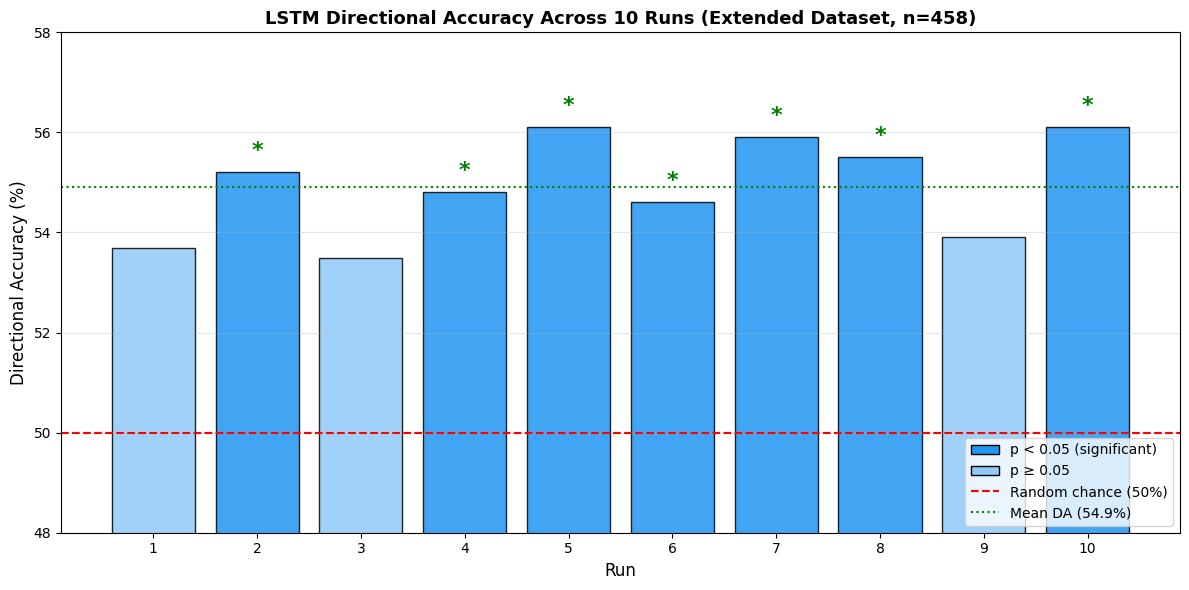

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

runs = list(range(1, 11))
da_values = [53.7, 55.2, 53.5, 54.8, 56.1, 54.6, 55.9, 55.5, 53.9, 56.1]
p_values = [0.0615, 0.0140, 0.0737, 0.0222, 0.0050, 0.0276, 0.0066, 0.0110, 0.0509, 0.0050]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2196F3' if p < 0.05 else '#90CAF9' for p in p_values]
bars = ax.bar(runs, da_values, color=colors, edgecolor='black', alpha=0.85)

ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Random chance (50%)')
ax.axhline(y=54.9, color='green', linestyle=':', linewidth=1.5, label='Mean DA (54.9%)')

for i, (da, p) in enumerate(zip(da_values, p_values)):
    if p < 0.05:
        ax.text(i+1, da + 0.3, '*', ha='center', fontsize=16, fontweight='bold', color='green')

ax.set_xlabel('Run', fontsize=12)
ax.set_ylabel('Directional Accuracy (%)', fontsize=12)
ax.set_title('LSTM Directional Accuracy Across 10 Runs (Extended Dataset, n=458)', fontsize=13, fontweight='bold')
ax.set_xticks(runs)
ax.set_ylim(48, 58)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', edgecolor='black', label='p < 0.05 (significant)'),
                   Patch(facecolor='#90CAF9', edgecolor='black', label='p ≥ 0.05'),
                   plt.Line2D([0],[0], color='red', linestyle='--', label='Random chance (50%)'),
                   plt.Line2D([0],[0], color='green', linestyle=':', label='Mean DA (54.9%)')]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('exp3_directional_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

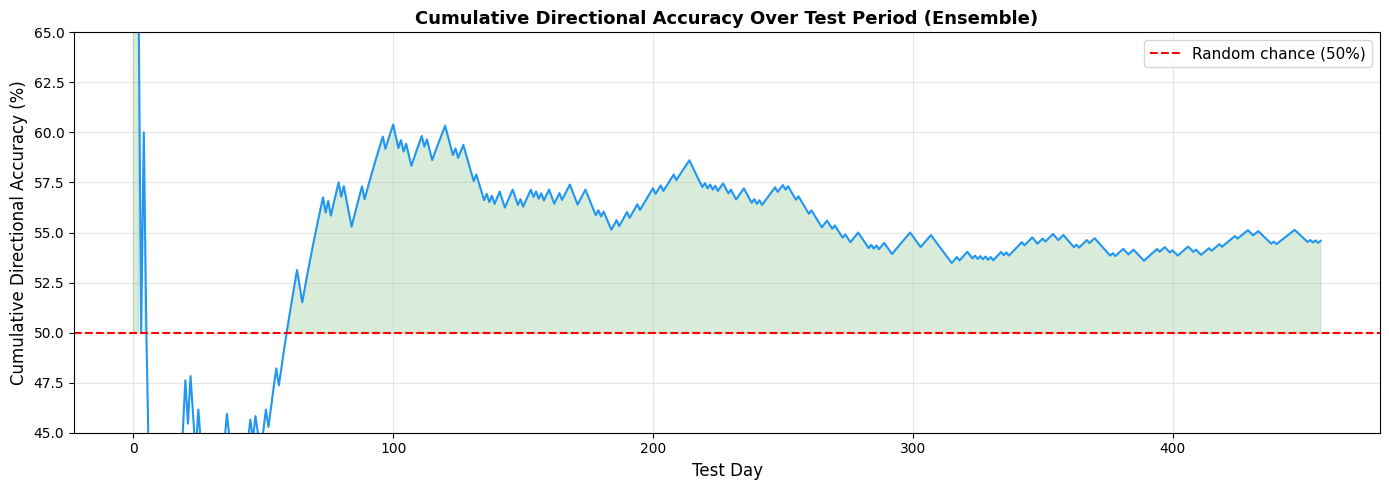

In [ ]:
cumulative_correct = np.cumsum(correct_mask)
cumulative_total = np.arange(1, len(correct_mask) + 1)
cumulative_acc = cumulative_correct / cumulative_total * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cumulative_acc, color='#2196F3', linewidth=1.5)
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5, label='Random chance (50%)')
ax.fill_between(range(len(cumulative_acc)), 50, cumulative_acc,
                where=cumulative_acc > 50, alpha=0.15, color='green')
ax.set_xlabel('Test Day', fontsize=12)
ax.set_ylabel('Cumulative Directional Accuracy (%)', fontsize=12)
ax.set_title('Cumulative Directional Accuracy Over Test Period (Ensemble)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(45, 65)
plt.tight_layout()
plt.savefig('exp3_cumulative_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

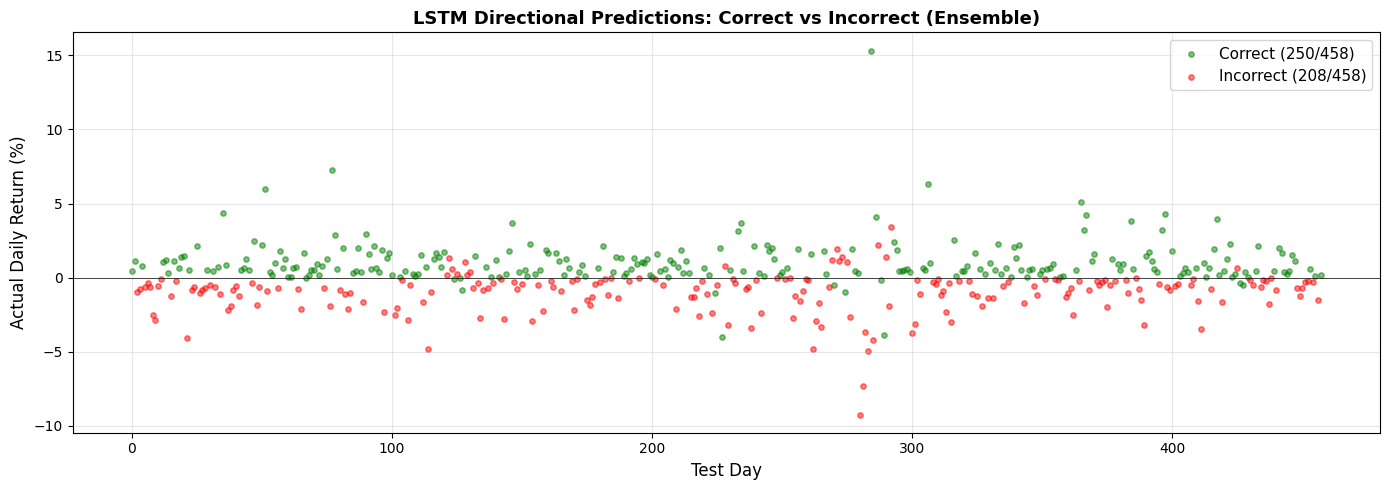

In [ ]:
# Use ensemble predictions
avg_prices = np.mean(all_preds, axis=0)
avg_returns = avg_prices / test_close_seq - 1
avg_dir = (avg_returns > 0).astype(int)
correct_mask = avg_dir == actual_direction

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(np.where(correct_mask)[0], y_test_returns_seq[correct_mask]*100,
           c='green', alpha=0.5, s=15, label=f'Correct ({correct_mask.sum()}/458)')
ax.scatter(np.where(~correct_mask)[0], y_test_returns_seq[~correct_mask]*100,
           c='red', alpha=0.5, s=15, label=f'Incorrect ({(~correct_mask).sum()}/458)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Test Day', fontsize=12)
ax.set_ylabel('Actual Daily Return (%)', fontsize=12)
ax.set_title('LSTM Directional Predictions: Correct vs Incorrect (Ensemble)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp3_direction_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

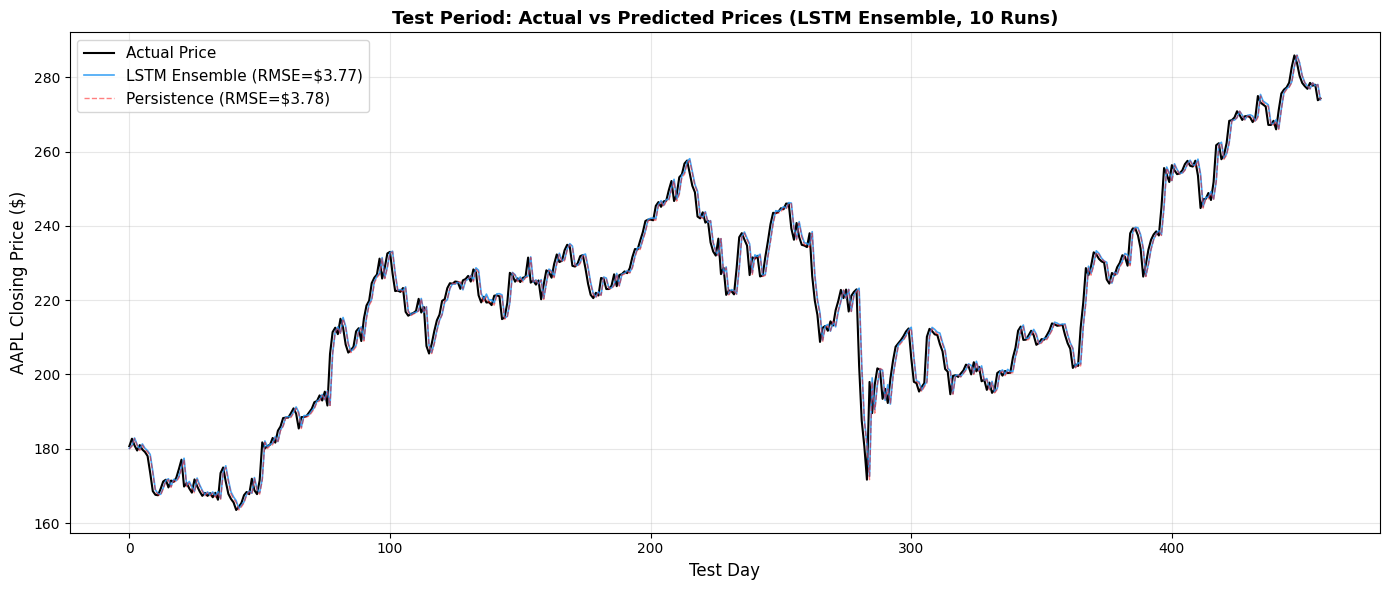

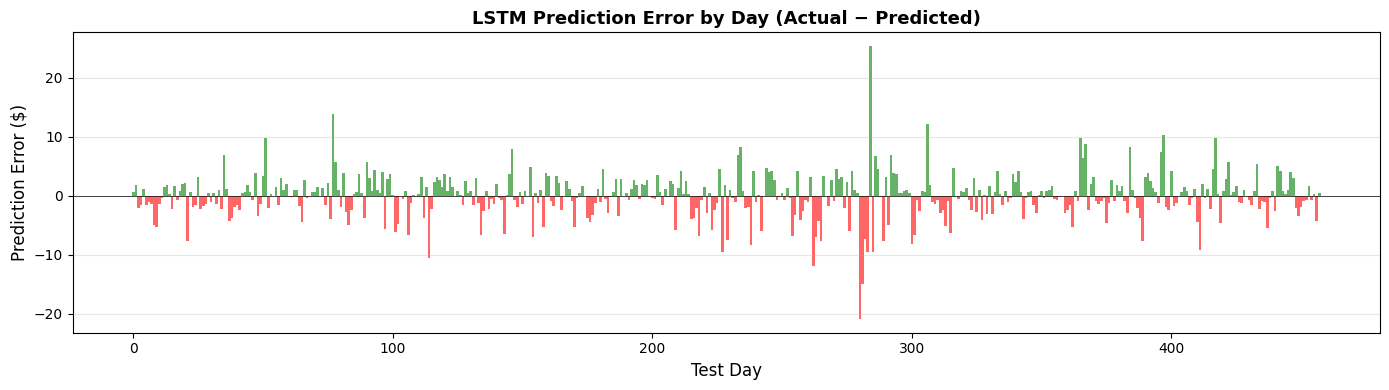

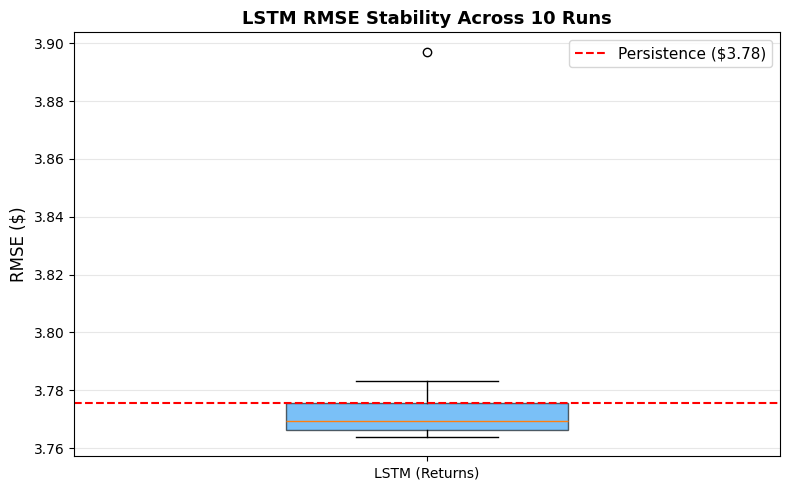

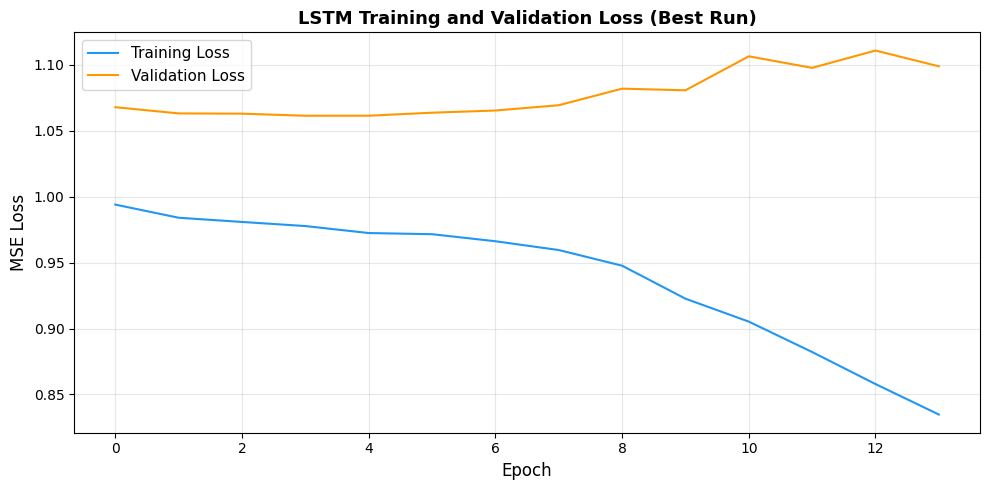

All figures saved.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Actual vs Predicted Price (ESSENTIAL — every paper has this) ──────────
fig, ax = plt.subplots(figsize=(14, 6))

avg_prices = np.mean(all_preds, axis=0)

ax.plot(y_test_price_actual, color='black', linewidth=1.5, label='Actual Price')
ax.plot(avg_prices, color='#2196F3', linewidth=1.2, alpha=0.85, label=f'LSTM Ensemble (RMSE=${np.sqrt(np.mean((y_test_price_actual - avg_prices)**2)):.2f})')
ax.plot(test_close_seq, color='red', linewidth=1.0, alpha=0.5, linestyle='--', label=f'Persistence (RMSE=${persist_rmse:.2f})')

ax.set_xlabel('Test Day', fontsize=12)
ax.set_ylabel('AAPL Closing Price ($)', fontsize=12)
ax.set_title('Test Period: Actual vs Predicted Prices (LSTM Ensemble, 10 Runs)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp3_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Prediction Error Over Time ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

errors = y_test_price_actual - avg_prices
ax.bar(range(len(errors)), errors, color=['green' if e > 0 else 'red' for e in errors], alpha=0.6, width=1.0)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Test Day', fontsize=12)
ax.set_ylabel('Prediction Error ($)', fontsize=12)
ax.set_title('LSTM Prediction Error by Day (Actual − Predicted)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('exp3_error_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. RMSE Stability Box Plot (10 runs) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

rmse_values = [r['RMSE'] for _, r in runs_df.iterrows()]
bp = ax.boxplot([rmse_values], labels=['LSTM (Returns)'], patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][0].set_alpha(0.6)

ax.axhline(y=persist_rmse, color='red', linestyle='--', linewidth=1.5, label=f'Persistence (${persist_rmse:.2f})')
ax.set_ylabel('RMSE ($)', fontsize=12)
ax.set_title('LSTM RMSE Stability Across 10 Runs', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('exp3_rmse_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Training Loss Curve (retrain best model to capture history) ───────────
seed = 1004  # Run 5 had best DA
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

model = build_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_seq, y_train_seq, validation_data=(X_val_seq, y_val_seq),
                    epochs=100, batch_size=32, callbacks=[es], verbose=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='Training Loss', color='#2196F3', linewidth=1.5)
ax.plot(history.history['val_loss'], label='Validation Loss', color='#FF9800', linewidth=1.5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('LSTM Training and Validation Loss (Best Run)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp3_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

del model
tf.keras.backend.clear_session()

print("All figures saved.")

In [ ]:
from scipy.stats import ttest_1samp

da_values = [53.7, 55.2, 53.5, 54.8, 56.1, 54.6, 55.9, 55.5, 53.9, 56.1]

t_stat, p_two = ttest_1samp(da_values, 50.0)
p_one = p_two / 2  # one-sided

print(f"Mean DA: {sum(da_values)/len(da_values):.1f}%")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value (one-sided): {p_one:.8f}")

Mean DA: 54.9%
t-statistic: 15.747
p-value (one-sided): 0.00000004


In [ ]:
# Training CO2 estimation
# Google Colab T4 GPU: ~70W TDP
# Source: https://mlco2.github.io/impact/

training_time_hours = (12 * 15) / 3600  # 12 epochs × ~15s per epoch = ~3 minutes
# 10 runs = ~30 minutes total
total_training_hours = 10 * training_time_hours

gpu_power_kw = 0.070  # T4 = 70W
pue = 1.1  # Power Usage Effectiveness for cloud
carbon_intensity = 0.233  # kgCO2/kWh (US average)

training_kwh = total_training_hours * gpu_power_kw * pue
training_co2 = training_kwh * carbon_intensity

# SHAP inference
shap_time_hours = 9.4 / 3600  # 9.4 seconds
shap_kwh = shap_time_hours * gpu_power_kw * pue
shap_co2 = shap_kwh * carbon_intensity

# Per 100 inferences (prof asked for this)
inference_time_per = 0.1  # ~0.1s per prediction
inference_100_hours = (100 * inference_time_per) / 3600
inference_100_kwh = inference_100_hours * gpu_power_kw * pue
inference_100_co2 = inference_100_kwh * carbon_intensity

print(f"CO2 Emissions Estimation")
print(f"{'='*50}")
print(f"Training (10 runs):     {training_co2*1000:.2f} gCO2")
print(f"SHAP analysis:          {shap_co2*1000:.4f} gCO2")
print(f"100 inferences:         {inference_100_co2*1000:.4f} gCO2")
print(f"Total project:          {(training_co2 + shap_co2)*1000:.2f} gCO2")
print(f"\nReference: ML CO2 Impact Calculator")
print("https://mlco2.github.io/impact/")

CO2 Emissions Estimation
Training (10 runs):     8.97 gCO2
SHAP analysis:          0.0468 gCO2
100 inferences:         0.0498 gCO2
Total project:          9.02 gCO2

Reference: ML CO2 Impact Calculator
https://mlco2.github.io/impact/


Train seq: (488, 30, 8), Val seq: (81, 30, 8)
Seeds: [np.int64(860), np.int64(6265), np.int64(15795), np.int64(37194), np.int64(44131), np.int64(54886), np.int64(60263), np.int64(76820), np.int64(82386), np.int64(87498)]
  Run  1 (seed=860): 44 epochs, train=0.001861, val=0.006540
  Run  2 (seed=6265): 11 epochs, train=0.002930, val=0.006802
  Run  3 (seed=15795): 51 epochs, train=0.001593, val=0.006858
  Run  4 (seed=37194): 12 epochs, train=0.002623, val=0.006790
  Run  5 (seed=44131): 11 epochs, train=0.003252, val=0.007380
  Run  6 (seed=54886): 21 epochs, train=0.002437, val=0.006375
  Run  7 (seed=60263): 11 epochs, train=0.003675, val=0.009548
  Run  8 (seed=76820): 29 epochs, train=0.002142, val=0.007337
  Run  9 (seed=82386): 11 epochs, train=0.003038, val=0.010244
  Run 10 (seed=87498): 32 epochs, train=0.002158, val=0.007587


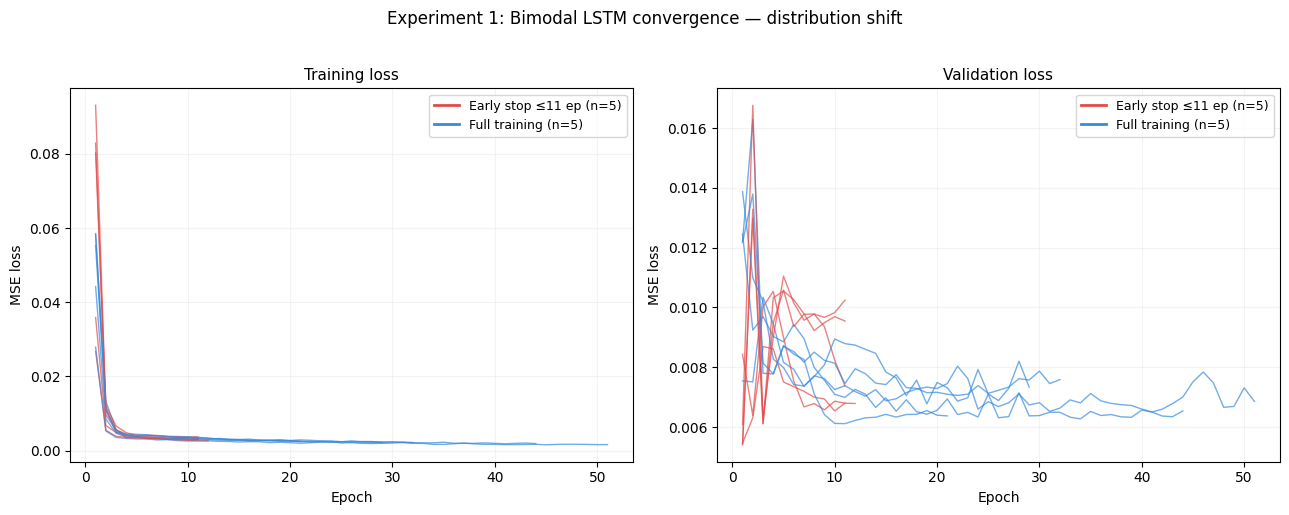

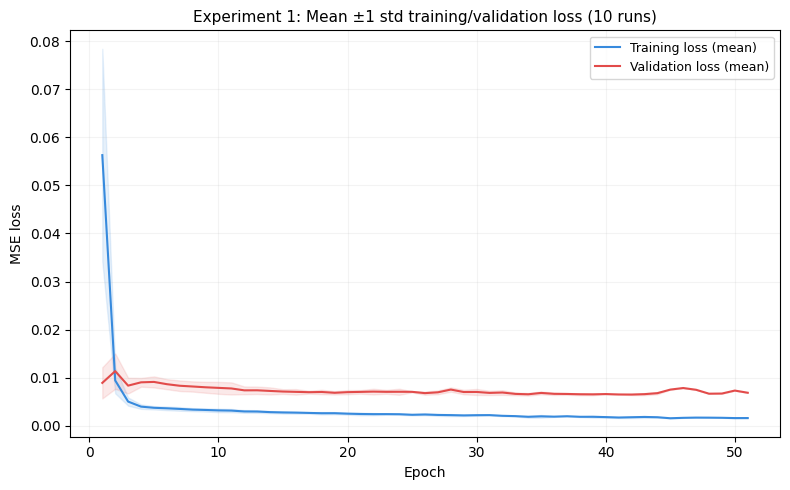

Done. Saved: exp1_individual_runs.png, exp1_mean_std.png


In [ ]:
"""
EXPERIMENT 1: CONVERGENCE ANALYSIS — fully self-contained
Just run this cell. Nothing else needed.
"""

import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import random, warnings
warnings.filterwarnings('ignore')

# ── 1. Data ──────────────────────────────────────────────────────
data = yf.download("AAPL", start="2022-12-19", end="2025-12-17", progress=False)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data = data.reset_index().sort_values('Date').reset_index(drop=True)
for col in ['Close','High','Low','Open','Volume']:
    data[col] = data[col].ffill().interpolate()

data['MA10'] = data['Close'].rolling(10, min_periods=1).mean()
data['MA30'] = data['Close'].rolling(30, min_periods=1).mean()
df = data.copy()
for lag in [1, 2, 3, 5, 10]:
    df[f'lag_close_{lag}'] = df['Close'].shift(lag)
df = df.dropna().reset_index(drop=True)

FEATURE_COLS = ['lag_close_1','lag_close_2','lag_close_3','lag_close_5',
                'lag_close_10','MA10','MA30','Volume']

n = len(df)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

scaler_X = MinMaxScaler().fit(df.iloc[:n_train][FEATURE_COLS])
scaler_y = MinMaxScaler().fit(df.iloc[:n_train][['Close']])

X_tr = scaler_X.transform(df.iloc[:n_train][FEATURE_COLS])
X_va = scaler_X.transform(df.iloc[n_train:n_train+n_val][FEATURE_COLS])
y_tr = scaler_y.transform(df.iloc[:n_train][['Close']]).flatten()
y_va = scaler_y.transform(df.iloc[n_train:n_train+n_val][['Close']]).flatten()

WINDOW = 30
def make_seq(X, y, w=30):
    Xs, ys = [], []
    for i in range(w, len(X)):
        Xs.append(X[i-w:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = make_seq(X_tr, y_tr, WINDOW)
X_val_seq, y_val_seq = make_seq(X_va, y_va, WINDOW)

print(f"Train seq: {X_train_seq.shape}, Val seq: {X_val_seq.shape}")

# ── 2. Run 10 times, capture loss curves ─────────────────────────
def build_lstm(input_shape):
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.1),
        LSTM(32),
        Dense(1)
    ])
    m.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return m

SEEDS = sorted(np.random.RandomState(42).randint(0, 100000, size=10))
print(f"Seeds: {SEEDS}")

lstm_histories = []
for run_i, seed in enumerate(SEEDS):
    np.random.seed(int(seed))
    tf.random.set_seed(int(seed))
    random.seed(int(seed))

    model = build_lstm((X_train_seq.shape[1], X_train_seq.shape[2]))
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train_seq, y_train_seq,
                        validation_data=(X_val_seq, y_val_seq),
                        epochs=100, batch_size=32, callbacks=[es], verbose=0)

    n_ep = len(history.history['loss'])
    lstm_histories.append({
        'run': run_i+1, 'seed': seed, 'epochs': n_ep,
        'train_loss': history.history['loss'],
        'val_loss': history.history['val_loss'],
    })
    print(f"  Run {run_i+1:2d} (seed={seed}): {n_ep} epochs, "
          f"train={history.history['loss'][-1]:.6f}, val={history.history['val_loss'][-1]:.6f}")
    del model
    tf.keras.backend.clear_session()

# ── 3. Plot: Individual runs (bimodal) ───────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for r in lstm_histories:
    n = r['epochs']
    x = range(1, n+1)
    color = '#E24B4A' if n <= 15 else '#378ADD'
    ax1.plot(x, r['train_loss'], color=color, alpha=0.7, lw=1)
    ax2.plot(x, r['val_loss'], color=color, alpha=0.7, lw=1)

n_early = sum(1 for r in lstm_histories if r['epochs'] <= 15)
legend_items = [
    Line2D([0],[0], color='#E24B4A', lw=2, label=f'Early stop ≤11 ep (n={n_early})'),
    Line2D([0],[0], color='#378ADD', lw=2, label=f'Full training (n={10-n_early})'),
]
for ax, title in [(ax1,'Training loss'), (ax2,'Validation loss')]:
    ax.set_title(title, fontsize=11, fontweight='medium')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
    ax.legend(handles=legend_items, fontsize=9); ax.grid(True, alpha=0.15)

plt.suptitle('Experiment 1: Bimodal LSTM convergence — distribution shift',
             fontsize=12, fontweight='medium', y=1.02)
plt.tight_layout()
plt.savefig('exp1_individual_runs.png', dpi=200, bbox_inches='tight')
plt.show()

# ── 4. Plot: Mean ± std ──────────────────────────────────────────
max_ep = max(r['epochs'] for r in lstm_histories)
train_mat = np.full((10, max_ep), np.nan)
val_mat = np.full((10, max_ep), np.nan)
for i, r in enumerate(lstm_histories):
    train_mat[i, :r['epochs']] = r['train_loss']
    val_mat[i, :r['epochs']] = r['val_loss']

ep_x = np.arange(1, max_ep+1)
t_mean, t_std = np.nanmean(train_mat, axis=0), np.nanstd(train_mat, axis=0)
v_mean, v_std = np.nanmean(val_mat, axis=0), np.nanstd(val_mat, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ep_x, t_mean, color='#378ADD', lw=1.5, label='Training loss (mean)')
ax.fill_between(ep_x, t_mean-t_std, t_mean+t_std, color='#378ADD', alpha=0.12)
ax.plot(ep_x, v_mean, color='#E24B4A', lw=1.5, label='Validation loss (mean)')
ax.fill_between(ep_x, v_mean-v_std, v_mean+v_std, color='#E24B4A', alpha=0.12)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Experiment 1: Mean ±1 std training/validation loss (10 runs)',
             fontsize=11, fontweight='medium')
ax.legend(fontsize=9); ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('exp1_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

print("Done. Saved: exp1_individual_runs.png, exp1_mean_std.png")

Data ready. Test samples: 82, Persistence RMSE: $3.34

LSTM Returns — 10 runs, NO fixed seeds
  Run  1: RMSE=$3.38, MAE=$2.45, DA=52.4%, Epochs=22, Time=25.6s
  Run  2: RMSE=$3.37, MAE=$2.47, DA=48.8%, Epochs=20, Time=14.9s


  Run  3: RMSE=$3.27, MAE=$2.35, DA=56.1%, Epochs=11, Time=9.7s
  Run  4: RMSE=$3.28, MAE=$2.34, DA=56.1%, Epochs=11, Time=10.1s
  Run  5: RMSE=$3.28, MAE=$2.36, DA=56.1%, Epochs=11, Time=10.4s
  Run  6: RMSE=$3.39, MAE=$2.42, DA=43.9%, Epochs=16, Time=12.9s
  Run  7: RMSE=$3.42, MAE=$2.45, DA=43.9%, Epochs=17, Time=13.7s
  Run  8: RMSE=$3.27, MAE=$2.35, DA=56.1%, Epochs=11, Time=10.5s
  Run  9: RMSE=$3.46, MAE=$2.47, DA=40.2%, Epochs=19, Time=14.3s
  Run 10: RMSE=$3.46, MAE=$2.50, DA=40.2%, Epochs=20, Time=14.3s

  LSTM Mean: RMSE=$3.36±0.08, MAE=$2.42±0.06, DA=49.4%±6.8%
  DA vs 50%: t=-0.2832, p(one-sided)=3.92e-01

ResNet-1D Returns — 10 runs, NO fixed seeds
  Run  1: RMSE=$3.30, MAE=$2.36, DA=56.1%, Epochs=12, Time=27.0s
  Run  2: RMSE=$3.30, MAE=$2.37, DA=56.1%, Epochs=12, Time=25.4s
  Run  3: RMSE=$3.51, MAE=$2.52, DA=43.9%, Epochs=17, Time=32.3s
  Run  4: RMSE=$3.45, MAE=$2.48, DA=43.9%, Epochs=17, Time=32.1s
  Run  5: RMSE=$4.05, MAE=$3.02, DA=58.5%, Epochs=31, Time=52.5s
  Ru

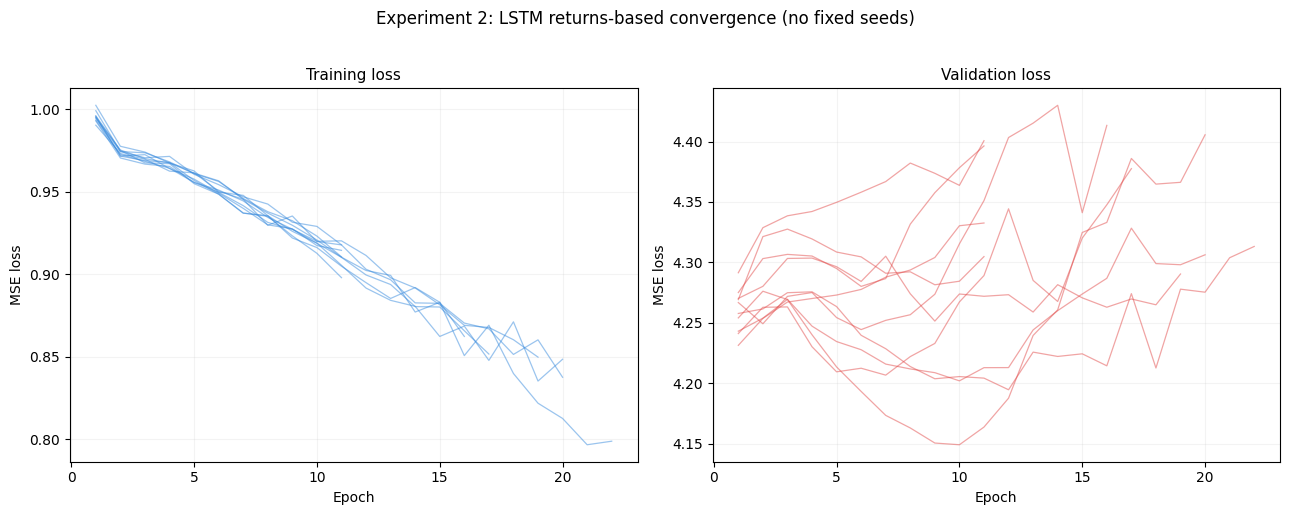

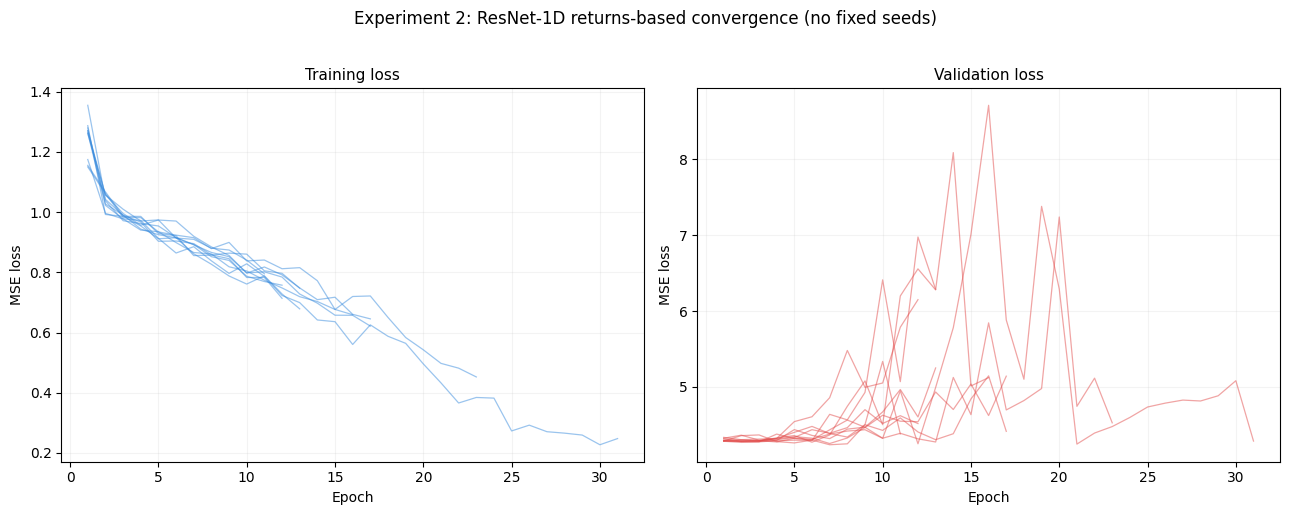


TABLES FOR REPORT

LSTM (Returns, 3yr, no fixed seeds):
 Run     RMSE      MAE      DA%   Epochs     Time
   1     3.38     2.45     52.4       22     25.6
   2     3.37     2.47     48.8       20     14.9
   3     3.27     2.35     56.1       11      9.7
   4     3.28     2.34     56.1       11     10.1
   5     3.28     2.36     56.1       11     10.4
   6     3.39     2.42     43.9       16     12.9
   7     3.42     2.45     43.9       17     13.7
   8     3.27     2.35     56.1       11     10.5
   9     3.46     2.47     40.2       19     14.3
  10     3.46     2.50     40.2       20     14.3
Mean     3.36     2.42     49.4
Std      0.08     0.06      6.8

ResNet-1D (Returns, 3yr, no fixed seeds):
 Run     RMSE      MAE      DA%   Epochs     Time
   1     3.30     2.36     56.1       12     27.0
   2     3.30     2.37     56.1       12     25.4
   3     3.51     2.52     43.9       17     32.3
   4     3.45     2.48     43.9       17     32.1
   5     4.05     3.02     58.5     

In [ ]:
"""
EXPERIMENT 2: Returns-based LSTM + ResNet-1D (NO fixed seeds, with convergence plots)
Fully self-contained. Just run this cell.
"""

import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import time, warnings
warnings.filterwarnings('ignore')

# ── 1. Data ──────────────────────────────────────────────────────
data = yf.download("AAPL", start="2022-12-19", end="2025-12-17", progress=False)
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data = data.reset_index().sort_values('Date').reset_index(drop=True)
for col in ['Close','High','Low','Open','Volume']:
    data[col] = data[col].ffill().interpolate()

df = data.copy()
df['Return'] = df['Close'].pct_change()
for lag in [1, 2, 3, 5, 10]:
    df[f'ret_lag_{lag}'] = df['Return'].shift(lag)
df['close_ma10_ratio'] = df['Close'] / df['Close'].rolling(10, min_periods=1).mean() - 1
df['close_ma30_ratio'] = df['Close'] / df['Close'].rolling(30, min_periods=1).mean() - 1
df['vol_change'] = df['Volume'].pct_change()
df['hl_range'] = (df['High'] - df['Low']) / df['Close']
df['oc_gap'] = (df['Close'] - df['Open']) / df['Open']
df['Target'] = df['Return'].shift(-1)
df = df.dropna().reset_index(drop=True)

FEAT = ['ret_lag_1','ret_lag_2','ret_lag_3','ret_lag_5','ret_lag_10',
        'close_ma10_ratio','close_ma30_ratio','vol_change','hl_range','oc_gap']

n = len(df)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

train_df = df.iloc[:n_train]
val_df = df.iloc[n_train:n_train+n_val]
test_df = df.iloc[n_train+n_val:]

scX = StandardScaler().fit(train_df[FEAT])
scy = StandardScaler().fit(train_df[['Target']])

X_tr = scX.transform(train_df[FEAT])
X_va = scX.transform(val_df[FEAT])
X_te = scX.transform(test_df[FEAT])
y_tr = scy.transform(train_df[['Target']]).flatten()
y_va = scy.transform(val_df[['Target']]).flatten()

test_close = test_df['Close'].values
y_test_returns = test_df['Target'].values

WINDOW = 30
def make_seq(X, y, w=30):
    Xs, ys = [], []
    for i in range(w, len(X)):
        Xs.append(X[i-w:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_tr_seq, y_tr_seq = make_seq(X_tr, y_tr, WINDOW)
X_va_seq, y_va_seq = make_seq(X_va, y_va, WINDOW)
X_te_seq, _ = make_seq(X_te, scy.transform(test_df[['Target']]).flatten(), WINDOW)

test_close_seq = test_close[WINDOW:]
y_test_ret_seq = y_test_returns[WINDOW:]
y_test_price_actual = test_close_seq * (1 + y_test_ret_seq)
actual_dir = (y_test_ret_seq > 0).astype(int)
n_test = len(actual_dir)

# Persistence baseline
persist_prices = test_close_seq.copy()
persist_rmse = np.sqrt(mean_squared_error(y_test_price_actual, persist_prices))
print(f"Data ready. Test samples: {n_test}, Persistence RMSE: ${persist_rmse:.2f}")

# ── 2. Model builders ────────────────────────────────────────────
def build_lstm(input_shape):
    m = tf.keras.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.1),
        layers.LSTM(32),
        layers.Dense(1)
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return m

def build_resnet(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv1D(64, 7, padding='same', activation='relu')(inp)
    for filters in [64, 128, 256]:
        shortcut = layers.Conv1D(filters, 1, padding='same')(x)
        x = layers.Conv1D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(0.1)(x)
        x = layers.Conv1D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Add()([x, shortcut])
        x = layers.Activation('relu')(x)
        x = layers.Dropout(0.1)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    out = layers.Dense(1)(x)
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return m

# ── 3. Run LSTM 10 times (NO fixed seeds) ────────────────────────
N_RUNS = 10

print(f"\n{'='*70}")
print(f"LSTM Returns — {N_RUNS} runs, NO fixed seeds")
print(f"{'='*70}")

lstm_runs = []
lstm_histories = []

for run_i in range(N_RUNS):
    t0 = time.time()
    model = build_lstm((X_tr_seq.shape[1], X_tr_seq.shape[2]))
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_tr_seq, y_tr_seq, validation_data=(X_va_seq, y_va_seq),
                        epochs=100, batch_size=32, callbacks=[es], verbose=0)
    elapsed = time.time() - t0
    n_ep = len(history.history['loss'])

    pred_scaled = model.predict(X_te_seq, verbose=0).flatten()
    pred_returns = scy.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    pred_prices = test_close_seq * (1 + pred_returns)
    pred_dir = (pred_returns > 0).astype(int)
    correct = np.sum(pred_dir == actual_dir)
    da = correct / n_test * 100

    rmse = np.sqrt(mean_squared_error(y_test_price_actual, pred_prices))
    mae = mean_absolute_error(y_test_price_actual, pred_prices)

    lstm_runs.append({'Run': run_i+1, 'RMSE': rmse, 'MAE': mae, 'DA': da,
                      'Epochs': n_ep, 'Time': elapsed})
    lstm_histories.append({'run': run_i+1, 'epochs': n_ep,
                           'train_loss': history.history['loss'],
                           'val_loss': history.history['val_loss']})

    print(f"  Run {run_i+1:2d}: RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%, "
          f"Epochs={n_ep}, Time={elapsed:.1f}s")
    del model
    tf.keras.backend.clear_session()

lstm_df = pd.DataFrame(lstm_runs)
print(f"\n  LSTM Mean: RMSE=${lstm_df['RMSE'].mean():.2f}±{lstm_df['RMSE'].std():.2f}, "
      f"MAE=${lstm_df['MAE'].mean():.2f}±{lstm_df['MAE'].std():.2f}, "
      f"DA={lstm_df['DA'].mean():.1f}%±{lstm_df['DA'].std():.1f}%")

t_stat, p_two = ttest_1samp(lstm_df['DA'].values, 50.0)
p_one = p_two / 2
print(f"  DA vs 50%: t={t_stat:.4f}, p(one-sided)={p_one:.2e}")

# ── 4. Run ResNet-1D 10 times (NO fixed seeds) ───────────────────
print(f"\n{'='*70}")
print(f"ResNet-1D Returns — {N_RUNS} runs, NO fixed seeds")
print(f"{'='*70}")

resnet_runs = []
resnet_histories = []

for run_i in range(N_RUNS):
    t0 = time.time()
    model = build_resnet((X_tr_seq.shape[1], X_tr_seq.shape[2]))
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_tr_seq, y_tr_seq, validation_data=(X_va_seq, y_va_seq),
                        epochs=100, batch_size=32, callbacks=[es], verbose=0)
    elapsed = time.time() - t0
    n_ep = len(history.history['loss'])

    pred_scaled = model.predict(X_te_seq, verbose=0).flatten()
    pred_returns = scy.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    pred_prices = test_close_seq * (1 + pred_returns)
    pred_dir = (pred_returns > 0).astype(int)
    correct = np.sum(pred_dir == actual_dir)
    da = correct / n_test * 100

    rmse = np.sqrt(mean_squared_error(y_test_price_actual, pred_prices))
    mae = mean_absolute_error(y_test_price_actual, pred_prices)

    resnet_runs.append({'Run': run_i+1, 'RMSE': rmse, 'MAE': mae, 'DA': da,
                        'Epochs': n_ep, 'Time': elapsed})
    resnet_histories.append({'run': run_i+1, 'epochs': n_ep,
                             'train_loss': history.history['loss'],
                             'val_loss': history.history['val_loss']})

    print(f"  Run {run_i+1:2d}: RMSE=${rmse:.2f}, MAE=${mae:.2f}, DA={da:.1f}%, "
          f"Epochs={n_ep}, Time={elapsed:.1f}s")
    del model
    tf.keras.backend.clear_session()

resnet_df = pd.DataFrame(resnet_runs)
print(f"\n  ResNet Mean: RMSE=${resnet_df['RMSE'].mean():.2f}±{resnet_df['RMSE'].std():.2f}, "
      f"DA={resnet_df['DA'].mean():.1f}%±{resnet_df['DA'].std():.1f}%")

t_stat_r, p_two_r = ttest_1samp(resnet_df['DA'].values, 50.0)
print(f"  DA vs 50%: t={t_stat_r:.4f}, p(one-sided)={p_two_r/2:.2e}")

# ── 5. Convergence plot: LSTM ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for r in lstm_histories:
    x = range(1, r['epochs']+1)
    ax1.plot(x, r['train_loss'], color='#378ADD', alpha=0.5, lw=0.9)
    ax2.plot(x, r['val_loss'], color='#E24B4A', alpha=0.5, lw=0.9)

ax1.set_title('Training loss', fontsize=11, fontweight='medium')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE loss'); ax1.grid(True, alpha=0.15)
ax2.set_title('Validation loss', fontsize=11, fontweight='medium')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE loss'); ax2.grid(True, alpha=0.15)
plt.suptitle('Experiment 2: LSTM returns-based convergence (no fixed seeds)',
             fontsize=12, fontweight='medium', y=1.02)
plt.tight_layout()
plt.savefig('exp2_lstm_convergence.png', dpi=200, bbox_inches='tight')
plt.show()

# ── 6. Convergence plot: ResNet-1D ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for r in resnet_histories:
    x = range(1, r['epochs']+1)
    ax1.plot(x, r['train_loss'], color='#378ADD', alpha=0.5, lw=0.9)
    ax2.plot(x, r['val_loss'], color='#E24B4A', alpha=0.5, lw=0.9)

ax1.set_title('Training loss', fontsize=11, fontweight='medium')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE loss'); ax1.grid(True, alpha=0.15)
ax2.set_title('Validation loss', fontsize=11, fontweight='medium')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE loss'); ax2.grid(True, alpha=0.15)
plt.suptitle('Experiment 2: ResNet-1D returns-based convergence (no fixed seeds)',
             fontsize=12, fontweight='medium', y=1.02)
plt.tight_layout()
plt.savefig('exp2_resnet_convergence.png', dpi=200, bbox_inches='tight')
plt.show()

# ── 7. Print tables for report ────────────────────────────────────
print(f"\n{'='*70}")
print("TABLES FOR REPORT")
print(f"{'='*70}")

print("\nLSTM (Returns, 3yr, no fixed seeds):")
print(f"{'Run':>4} {'RMSE':>8} {'MAE':>8} {'DA%':>8} {'Epochs':>8} {'Time':>8}")
for _, r in lstm_df.iterrows():
    print(f"{int(r['Run']):4d} {r['RMSE']:8.2f} {r['MAE']:8.2f} {r['DA']:8.1f} {int(r['Epochs']):8d} {r['Time']:8.1f}")
print(f"Mean {lstm_df['RMSE'].mean():8.2f} {lstm_df['MAE'].mean():8.2f} {lstm_df['DA'].mean():8.1f}")
print(f"Std  {lstm_df['RMSE'].std():8.2f} {lstm_df['MAE'].std():8.2f} {lstm_df['DA'].std():8.1f}")

print(f"\nResNet-1D (Returns, 3yr, no fixed seeds):")
print(f"{'Run':>4} {'RMSE':>8} {'MAE':>8} {'DA%':>8} {'Epochs':>8} {'Time':>8}")
for _, r in resnet_df.iterrows():
    print(f"{int(r['Run']):4d} {r['RMSE']:8.2f} {r['MAE']:8.2f} {r['DA']:8.1f} {int(r['Epochs']):8d} {r['Time']:8.1f}")
print(f"Mean {resnet_df['RMSE'].mean():8.2f} {resnet_df['MAE'].mean():8.2f} {resnet_df['DA'].mean():8.1f}")
print(f"Std  {resnet_df['RMSE'].std():8.2f} {resnet_df['MAE'].std():8.2f} {resnet_df['DA'].std():8.1f}")

print("\nDone. Saved: exp2_lstm_convergence.png, exp2_resnet_convergence.png")

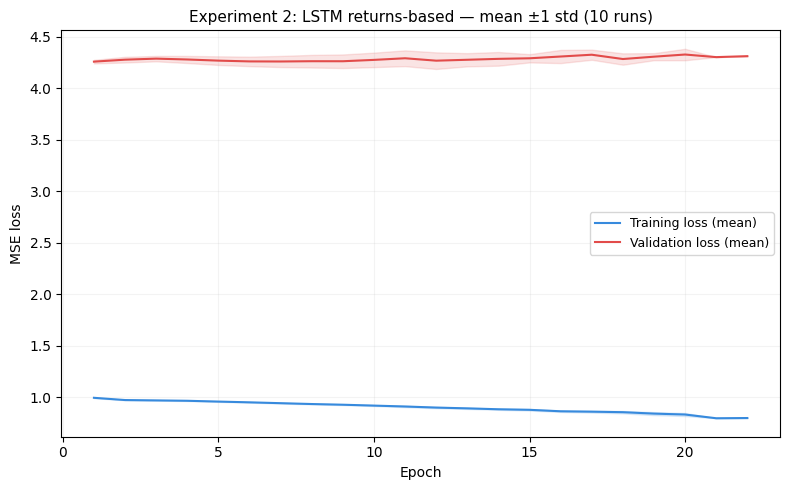

Saved: exp2_lstm_mean_std.png


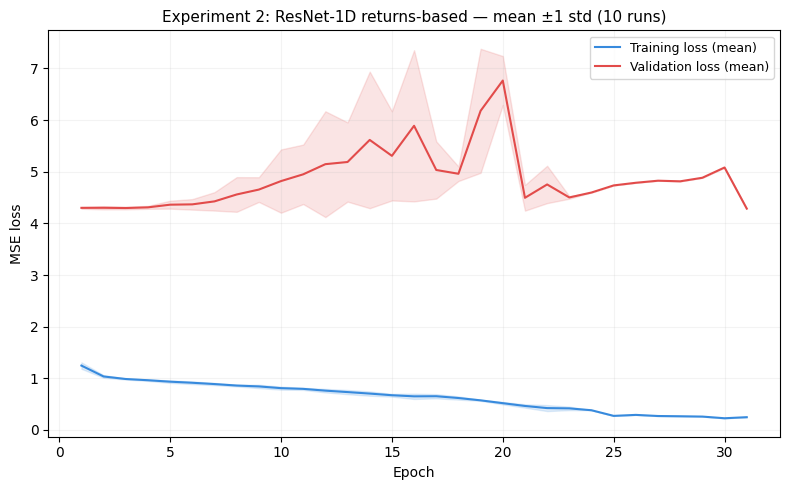

Saved: exp2_resnet_mean_std.png


In [ ]:
"""
Experiment 2: Mean ± std convergence plots (2 clean lines, not 10)
"""
import numpy as np
import matplotlib.pyplot as plt

def plot_mean_std(histories, title, filename):
    max_ep = max(r['epochs'] for r in histories)
    n = len(histories)
    train_mat = np.full((n, max_ep), np.nan)
    val_mat = np.full((n, max_ep), np.nan)
    for i, r in enumerate(histories):
        train_mat[i, :r['epochs']] = r['train_loss']
        val_mat[i, :r['epochs']] = r['val_loss']

    ep = np.arange(1, max_ep + 1)
    t_mean, t_std = np.nanmean(train_mat, axis=0), np.nanstd(train_mat, axis=0)
    v_mean, v_std = np.nanmean(val_mat, axis=0), np.nanstd(val_mat, axis=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ep, t_mean, color='#378ADD', lw=1.5, label='Training loss (mean)')
    ax.fill_between(ep, t_mean - t_std, t_mean + t_std, color='#378ADD', alpha=0.15)
    ax.plot(ep, v_mean, color='#E24B4A', lw=1.5, label='Validation loss (mean)')
    ax.fill_between(ep, v_mean - v_std, v_mean + v_std, color='#E24B4A', alpha=0.15)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.set_title(title, fontsize=11, fontweight='medium')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.15)
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

plot_mean_std(lstm_histories,
              'Experiment 2: LSTM returns-based — mean ±1 std (10 runs)',
              'exp2_lstm_mean_std.png')

plot_mean_std(resnet_histories,
              'Experiment 2: ResNet-1D returns-based — mean ±1 std (10 runs)',
              'exp2_resnet_mean_std.png')